In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
mainfolder = '/content/drive/MyDrive/Trabajos/leptoquarks/scalar-vs-vector/03-pythons2026-junio/'

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import gridspec

import os
import joblib  # to save the scaler

from numba import njit # for the LQ mass reconstruction

from scipy.optimize import fsolve, minimize
from scipy import stats
from scipy.stats import poisson
from scipy.stats import ks_2samp
from scipy.stats import anderson_ksamp
from scipy.stats import wasserstein_distance
from scipy.stats import chisquare
from scipy.interpolate import interp1d

import math
import random

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Conv2D, Flatten, MaxPooling2D, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from sklearn import preprocessing
from sklearn.metrics import roc_curve, roc_auc_score, auc, accuracy_score
from sklearn.metrics import mean_squared_error, r2_score

from xgboost import XGBRegressor, XGBClassifier
import xgboost as xgb

# LOAD DATA

## Background

In [4]:
CHs_selected = ["tt", "singletP1", "singletP2", "Wbbjets", "ttW", "ttZ", "ttH"]


df_B_all = {}
X_B_all = {}


output_folder = mainfolder + "../DATA/backgrounds/data_df/"

for CH_sel in CHs_selected:
    # Read the file
    if CH_sel == 'singletP2':
        filename = mainfolder + '../DATA-wjets/backgrounds/dats-singlet-comp/df_' + CH_sel + ".csv"
    else:
        filename = mainfolder + '../DATA-wjets/backgrounds/dats-' + CH_sel + '/df_' + CH_sel + ".csv"

    df_temp = pd.read_csv(filename)

    # get the features
    feats_label = [c for c in df_temp.columns]

    # Save in the dictionary
    df_B_all[CH_sel] = df_temp
    X_B_all[CH_sel] = df_temp[feats_label].values

    # Print
    print(f"X_{CH_sel}.shape: {X_B_all[CH_sel].shape}")

X_tt.shape: (826022, 53)
X_singletP1.shape: (179677, 53)
X_singletP2.shape: (94219, 53)
X_Wbbjets.shape: (162448, 53)
X_ttW.shape: (141919, 53)
X_ttZ.shape: (16178, 53)
X_ttH.shape: (12068, 53)


## Signal SLQ

In [5]:
masses_SLQ = [1000, 1100, 1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900]


df_SLQ_all = {}
X_SLQ_all = {}


output_folder = mainfolder + "../DATA/signal/data_df/"

for mass_sel in masses_SLQ:
    # Read the file
    filename = mainfolder + '../DATA-wjets/signals/dats-SLQ-' + str(mass_sel) + 'GeV/df_SLQ_' + str(mass_sel) + "GeV.csv"

    df_temp = pd.read_csv(filename)

    # get the features
    feats_label = [c for c in df_temp.columns]

    # Save in the dictionary
    df_SLQ_all[mass_sel] = df_temp
    X_SLQ_all[mass_sel] = df_temp[feats_label].values

    # Print
    print(f"X_SLQ_{mass_sel}GeV.shape: {X_SLQ_all[mass_sel].shape}")

X_SLQ_1000GeV.shape: (267452, 53)
X_SLQ_1100GeV.shape: (271062, 53)
X_SLQ_1200GeV.shape: (534247, 53)
X_SLQ_1300GeV.shape: (196510, 53)
X_SLQ_1400GeV.shape: (506381, 53)
X_SLQ_1500GeV.shape: (185940, 53)
X_SLQ_1600GeV.shape: (481827, 53)
X_SLQ_1700GeV.shape: (173573, 53)
X_SLQ_1800GeV.shape: (301687, 53)
X_SLQ_1900GeV.shape: (64690, 53)


## Signal VLQ

In [6]:
masses_VLQ = [1400, 1500, 1600, 1700, 1800, 1900, 2000, 2100, 2200, 2300]

df_VLQ_all = {}
X_VLQ_all = {}


output_folder = mainfolder + "../DATA/signal/data_df/"

for mass_sel in masses_VLQ:
    # Read the file
    filename = mainfolder + '../DATA-wjets/signals/dats-VLQ-' + str(mass_sel) + 'GeV/df_VLQ_' + str(mass_sel) + "GeV.csv"

    df_temp = pd.read_csv(filename)

    # get the features
    feats_label = [c for c in df_temp.columns]

    # Save in the dictionary
    df_VLQ_all[mass_sel] = df_temp
    X_VLQ_all[mass_sel] = df_temp[feats_label].values

    # Print
    print(f"X_VLQ_{mass_sel}GeV.shape: {X_VLQ_all[mass_sel].shape}")

X_VLQ_1400GeV.shape: (139696, 53)
X_VLQ_1500GeV.shape: (293700, 53)
X_VLQ_1600GeV.shape: (134774, 53)
X_VLQ_1700GeV.shape: (192819, 53)
X_VLQ_1800GeV.shape: (127670, 53)
X_VLQ_1900GeV.shape: (75898, 53)
X_VLQ_2000GeV.shape: (184097, 53)
X_VLQ_2100GeV.shape: (72762, 53)
X_VLQ_2200GeV.shape: (232166, 53)
X_VLQ_2300GeV.shape: (64705, 53)


# Cross Section

In [7]:
Lum = 139

In [8]:
# -------------------------
# cross sections
# -------------------------
k_LQ = 1.8877462860822058

xsec_file_13TeV = mainfolder + '../DATA-wjets/signals/LQs-xsec-13TeV.txt'

xsec_data_13TeV = np.loadtxt(xsec_file_13TeV, comments='#')

# columns: 0=mass, 1=SLQ, 2=VLQ
masses_13TeV = xsec_data_13TeV[:,0].astype(int)
fidxsec_SLQ_13TeV = dict(zip(masses_13TeV, xsec_data_13TeV[:,1]*k_LQ))
fidxsec_VLQ_13TeV = dict(zip(masses_13TeV, xsec_data_13TeV[:,2]*k_LQ))


masses_SLQ_13TeV = [1200, 1400, 1600, 1800, 2000, 2200]
masses_VLQ_13TeV = [1200, 1400, 1600, 1800, 2000, 2200]

fidxsec_SLQ_non0_13TeV = [fidxsec_SLQ_13TeV[ii] for ii in masses_SLQ_13TeV]
fidxsec_VLQ_non0_13TeV = [fidxsec_VLQ_13TeV[ii] for ii in masses_VLQ_13TeV]


#  interpolate
f_xsec_SLQ_log_13TeV = interp1d(masses_SLQ_13TeV, np.log10(fidxsec_SLQ_non0_13TeV), kind='linear', fill_value="extrapolate")
f_xsec_VLQ_log_13TeV = interp1d(masses_VLQ_13TeV, np.log10(fidxsec_VLQ_non0_13TeV), kind='linear', fill_value="extrapolate")



# -------------------------
# cross sections
# -------------------------
xsec_file_betas_13TeV = mainfolder + '../DATA-wjets/signals/LQs-xsec-13TeV-betas.txt'

xsec_data_betas_13TeV = np.loadtxt(xsec_file_betas_13TeV, comments='#')

# columns: 0=beta, 1,...=SLQ, -1=ratio=fid_xsec(beta)/fid_xsec(beta=0.5)
betas = xsec_data_betas_13TeV[:,0]
ratio_mean_13TeV = xsec_data_betas_13TeV[:,-1]

#  interpolate
f_ratio_SLQ_log_13TeV = interp1d(betas, ratio_mean_13TeV, kind='linear', fill_value="extrapolate")
f_ratio_VLQ_log_13TeV = interp1d(betas, ratio_mean_13TeV, kind='linear', fill_value="extrapolate")



# FINAL FUNCTIONS
def fid_xsec_SLQ_13TeV(mass, beta):
    return 10**f_xsec_SLQ_log_13TeV(mass) * f_ratio_SLQ_log_13TeV(beta)

def fid_xsec_VLQ_13TeV(mass, beta):
    return 10**f_xsec_VLQ_log_13TeV(mass) * f_ratio_VLQ_log_13TeV(beta)

In [9]:
masses = [1000, 1100, 1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900, 2000, 2100, 2200, 2300]

beta = 0.5

fidxsec_SLQ = dict(zip(masses, fid_xsec_SLQ_13TeV(masses, beta)))
fidxsec_VLQ = dict(zip(masses, fid_xsec_VLQ_13TeV(masses, beta)))


print('masses: ', masses)
print(fidxsec_SLQ[1200], '[fb]')
print(fidxsec_VLQ[1600], '[fb]')

masses:  [1000, 1100, 1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900, 2000, 2100, 2200, 2300]
0.09349663785141098 [fb]
0.08190419556067163 [fb]


In [10]:
# -----------------------------------
# LQs number and fid cross sections
# -----------------------------------

for m_it in masses_SLQ:
    print(f"# eventos SLQ {m_it} GeV:", len(X_SLQ_all[m_it]), "  fid_xsec = ", fidxsec_SLQ[m_it], "[fb]")

print(" ")
for m_it in masses_VLQ:
    print(f"# eventos VLQ {m_it} GeV:", len(X_VLQ_all[m_it]), "  fid_xsec = ", fidxsec_VLQ[m_it], "[fb]")

# eventos SLQ 1000 GeV: 267452   fid_xsec =  0.3730835911561011 [fb]
# eventos SLQ 1100 GeV: 271062   fid_xsec =  0.18676739921791988 [fb]
# eventos SLQ 1200 GeV: 534247   fid_xsec =  0.09349663785141098 [fb]
# eventos SLQ 1300 GeV: 196510   fid_xsec =  0.04680485634068387 [fb]
# eventos SLQ 1400 GeV: 506381   fid_xsec =  0.02343073106600481 [fb]
# eventos SLQ 1500 GeV: 185940   fid_xsec =  0.013119674274335682 [fb]
# eventos SLQ 1600 GeV: 481827   fid_xsec =  0.007346158025534233 [fb]
# eventos SLQ 1700 GeV: 173573   fid_xsec =  0.003971497803273693 [fb]
# eventos SLQ 1800 GeV: 301687   fid_xsec =  0.0021470807933322007 [fb]
# eventos SLQ 1900 GeV: 64690   fid_xsec =  0.0011742466241982435 [fb]
 
# eventos VLQ 1400 GeV: 139696   fid_xsec =  0.2721067871940437 [fb]
# eventos VLQ 1500 GeV: 293700   fid_xsec =  0.1492872650688163 [fb]
# eventos VLQ 1600 GeV: 134774   fid_xsec =  0.08190419556067163 [fb]
# eventos VLQ 1700 GeV: 192819   fid_xsec =  0.045091784372215574 [fb]
# eventos VLQ 

In [11]:
# FOR 13 TeV

k_fakett = 1.1053030485310749
crossfid_fakett = 0.19136
k_tt = 1.2593273872014419
crossfid_tt = (5.1373984*k_tt) + (crossfid_fakett * k_fakett)


fidxsec_SM = {'tt': crossfid_tt,
              'singletP1': 0.39648 * 3.440676833094312,
              'singletP2': 0.283008 * 3.440676833094312,
              'Wbbjets': 0.9988452079186325 * 0.9781509289273502,
              'ttW': 0.0231785208 * 3.056401327463198,
              'ttZ': 0.050087088 * 3.056401327463198,
              'ttH': 0.025004896 * 2.2127445612386474
              }

for ch_it in fidxsec_SM:
    print(f"# eventos {ch_it}:", len(X_B_all[ch_it]), "  fid_xsec = ", fidxsec_SM[ch_it], "[fb]")

# eventos tt: 826022   fid_xsec =  6.681177295451775 [fb]
# eventos singletP1: 179677   fid_xsec =  1.3641595507852329 [fb]
# eventos singletP2: 94219   fid_xsec =  0.973739069180355 [fb]
# eventos Wbbjets: 162448   fid_xsec =  0.9770213679802426 [fb]
# eventos ttW: 141919   fid_xsec =  0.07084286174175335 [fb]
# eventos ttZ: 16178   fid_xsec =  0.15308624225196601 [fb]
# eventos ttH: 12068   fid_xsec =  0.055329447628338004 [fb]


In [12]:
# # FOR 13.6 TeV

# k_fakett = 1.1053030485310749
# crossfid_fakett = 0.222944
# k_tt = 1.2593273872014419
# crossfid_tt = (6.70014736*k_tt) + (crossfid_fakett * k_fakett)


# fidxsec_SM = {'tt': crossfid_tt,
#               'singletP1': 0.5381712 * 3.440676833094312,
#               'singletP2': 0.30416544 * 3.440676833094312,
#               'Wbbjets': 1.3920832941861587 * 0.9781509289273502,
#               'ttW': 0.03137058432 * 3.056401327463198,
#               'ttZ': 0.06296147519999999 * 3.056401327463198,
#               'ttH': 0.0317827504 * 2.2127445612386474
#               }

# for ch_it in fidxsec_SM:
#     print(f"# eventos {ch_it}:", len(X_B_all[ch_it]), "  fid_xsec = ", fidxsec_SM[ch_it], "[fb]")

In [13]:
# # FOR 14 TeV

# k_fakett = 1.1053030485310749
# crossfid_fakett = 0.244
# k_tt = 1.2593273872014419
# crossfid_tt = (7.74198*k_tt) + (crossfid_fakett * k_fakett)


# fidxsec_SM = {'tt': crossfid_tt,
#               'singletP1': 0.632632 * 3.440676833094312,
#               'singletP2': 0.3182704 * 3.440676833094312,
#               'Wbbjets': 1.6542420183645095 * 0.9781509289273502,
#               'ttW': 0.03683196 * 3.056401327463198,
#               'ttZ': 0.0715444 * 3.056401327463198,
#               'ttH': 0.03630132 * 2.2127445612386474
#               }

# for ch_it in fidxsec_SM:
#     print(f"# eventos {ch_it}:", len(X_B_all[ch_it]), "  fid_xsec = ", fidxsec_SM[ch_it], "[fb]")

In [14]:
# MAX SM dataset
totalcrossSM = sum([fidxsec_SM[ch_it] for ch_it in fidxsec_SM])


weigth_gen_SM = {}

for ch_it in fidxsec_SM:

    print(f"fraction of {ch_it}:", fidxsec_SM[ch_it] / totalcrossSM )

    weigth_gen_SM[ch_it] = len(X_B_all[ch_it]) / (fidxsec_SM[ch_it] / totalcrossSM)

print('\nchannel limiting the SM background: ', min(weigth_gen_SM, key=weigth_gen_SM.get) , '\n')


max_evs_SM = {}

for ch_it in fidxsec_SM:
    max_evs_SM[ch_it] = round( min(weigth_gen_SM.values()) * (fidxsec_SM[ch_it] / totalcrossSM) )
    print(f"# eventos {ch_it} (max):", max_evs_SM[ch_it])

max_SM_dataset = sum(max_evs_SM.values())
print('\nmax SM dataset length: ', max_SM_dataset )

fraction of tt: 0.6502137154882276
fraction of singletP1: 0.13276032214242267
fraction of singletP2: 0.09476451081739999
fraction of Wbbjets: 0.09508394489370722
fraction of ttW: 0.006894443645475736
fraction of ttZ: 0.014898388407166346
fraction of ttH: 0.0053846746056003736

channel limiting the SM background:  singletP2 

# eventos tt (max): 646471
# eventos singletP1 (max): 131996
# eventos singletP2 (max): 94219
# eventos Wbbjets (max): 94537
# eventos ttW (max): 6855
# eventos ttZ (max): 14813
# eventos ttH (max): 5354

max SM dataset length:  994245


In [15]:
masses_VLQ

[1400, 1500, 1600, 1700, 1800, 1900, 2000, 2100, 2200, 2300]

## Number of events to get a balanced dataset

In [16]:
# -------------------------
# Step 1: minimim number of events in LQs (selected mass)
# -------------------------

num_data_SLQ = [len(X_SLQ_all[m_it]) for m_it in masses_SLQ]

num_data_VLQ = [len(X_VLQ_all[m_it]) for m_it in masses_VLQ]


max_SM_dataset = min(750000, max_SM_dataset)

num_data_NP = min(int(max_SM_dataset / (len(masses_SLQ) + len(masses_VLQ))) , min(num_data_SLQ + num_data_VLQ) )

print('SIGNAL: # events per-class chosen =', num_data_NP)



# -------------------------
# Step 2: background total fid_xsec
# -------------------------
totalcrossSM = sum([fidxsec_SM[ch_it] for ch_it in fidxsec_SM])



# -------------------------
# Step 3: number of events per chanel, proportional to xsec
# -------------------------
num_data_SM_dict = {}
for ch_it in fidxsec_SM:
    if ch_it == 'tt':
        # set at the end to have exactly the same # events (otherwise can be a difference of 1 due to rounding)
        continue
    fraction = fidxsec_SM[ch_it]/totalcrossSM
    num_data_SM_dict[ch_it] = round(num_data_NP * fraction * (len(masses_SLQ) + len(masses_VLQ)) )

# Set tt such that the total matches num_data_NP
num_data_SM_dict['tt'] = num_data_NP * (len(masses_SLQ) + len(masses_VLQ)) - sum([v for k,v in num_data_SM_dict.items() if k != 'tt'])



print('\nBACKGROUND events chosen (weighted by xsec):')
for ch_it in fidxsec_SM:
    print(f'# {ch_it}: {num_data_SM_dict[ch_it]}')
print('# total B events chosen: ', sum(num_data_SM_dict.values()))

SIGNAL: # events per-class chosen = 37500

BACKGROUND events chosen (weighted by xsec):
# tt: 487660
# singletP1: 99570
# singletP2: 71073
# Wbbjets: 71313
# ttW: 5171
# ttZ: 11174
# ttH: 4039
# total B events chosen:  750000


In [17]:
# keep just the events needed

for m_it in masses_SLQ:
    X_SLQ_all[m_it] = X_SLQ_all[m_it][:num_data_NP]
    df_SLQ_all[m_it] = df_SLQ_all[m_it][:num_data_NP]

print(" ")
for m_it in masses_VLQ:
    X_VLQ_all[m_it] = X_VLQ_all[m_it][:num_data_NP]
    df_VLQ_all[m_it] = df_VLQ_all[m_it][:num_data_NP]

print("")
for ch_it in fidxsec_SM:
    X_B_all[ch_it] = X_B_all[ch_it][:num_data_SM_dict[ch_it]]
    df_B_all[ch_it] = df_B_all[ch_it][:num_data_SM_dict[ch_it]]

In [18]:
B_expected = round(Lum * totalcrossSM)    # luminosity * cross * aceptance
print('B_expected: ', B_expected)

for ch_it in fidxsec_SM:
    print(f" channel {ch_it}:", "  fid_xsec = ", fidxsec_SM[ch_it], "[fb]", " B_exp_ch: ", round(Lum * fidxsec_SM[ch_it]) )


S_expected_SLQ = []

for m_it in masses_SLQ:
    S_expected_SLQ.append( round(Lum * fidxsec_SLQ[m_it]) )

print('\nmasses:           ', masses_SLQ)
print('S_expected (SLQ): ', S_expected_SLQ)    # luminosity * cross * aceptance



S_expected_VLQ = []

for m_it in masses_VLQ:
    S_expected_VLQ.append( round(Lum * fidxsec_VLQ[m_it]) )

print('\nmasses:           ', masses_VLQ)
print('S_expected (VLQ): ', S_expected_VLQ)    # luminosity * cross * aceptance

B_expected:  1428
 channel tt:   fid_xsec =  6.681177295451775 [fb]  B_exp_ch:  929
 channel singletP1:   fid_xsec =  1.3641595507852329 [fb]  B_exp_ch:  190
 channel singletP2:   fid_xsec =  0.973739069180355 [fb]  B_exp_ch:  135
 channel Wbbjets:   fid_xsec =  0.9770213679802426 [fb]  B_exp_ch:  136
 channel ttW:   fid_xsec =  0.07084286174175335 [fb]  B_exp_ch:  10
 channel ttZ:   fid_xsec =  0.15308624225196601 [fb]  B_exp_ch:  21
 channel ttH:   fid_xsec =  0.055329447628338004 [fb]  B_exp_ch:  8

masses:            [1000, 1100, 1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900]
S_expected (SLQ):  [52, 26, 13, 7, 3, 2, 1, 1, 0, 0]

masses:            [1400, 1500, 1600, 1700, 1800, 1900, 2000, 2100, 2200, 2300]
S_expected (VLQ):  [38, 21, 11, 6, 3, 2, 1, 1, 0, 0]


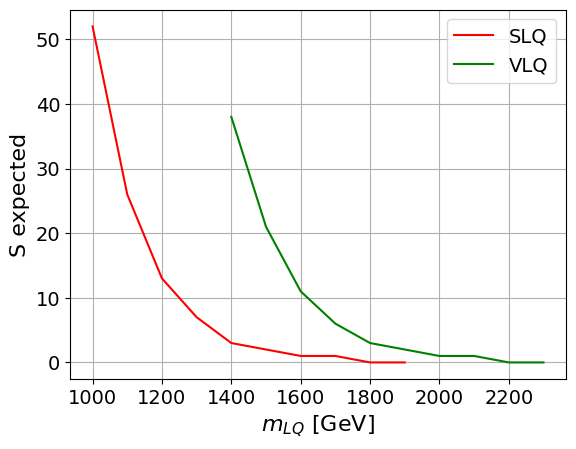

In [19]:
plt.plot(masses_SLQ, S_expected_SLQ, color='red', label='SLQ')
plt.plot(masses_VLQ, S_expected_VLQ, color='green', label='VLQ')
# plt.yscale('log')
plt.xlabel("$m_{LQ}$ [GeV]", fontsize=16)
plt.ylabel("S expected", fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid()
plt.legend(fontsize=14)
plt.show()

In [20]:
matched_VLQ_masses = []

for s_ev in S_expected_SLQ:
    # buscamos la VLQ que tenga la menor diferencia de eventos
    idx_match = np.argmin([abs(vlq_ev - s_ev) for vlq_ev in S_expected_VLQ])
    matched_mass = masses_VLQ[idx_match]
    matched_VLQ_masses.append(matched_mass)

# Mostrar resultados
for slq, s_ev, vlq, v_ev in zip(masses_SLQ, S_expected_SLQ, matched_VLQ_masses,
                                 [S_expected_VLQ[masses_VLQ.index(m)] for m in matched_VLQ_masses]):
    print(f"SLQ {slq} GeV ({s_ev} ev)  -> VLQ {vlq} GeV ({v_ev} ev)")

SLQ 1000 GeV (52 ev)  -> VLQ 1400 GeV (38 ev)
SLQ 1100 GeV (26 ev)  -> VLQ 1500 GeV (21 ev)
SLQ 1200 GeV (13 ev)  -> VLQ 1600 GeV (11 ev)
SLQ 1300 GeV (7 ev)  -> VLQ 1700 GeV (6 ev)
SLQ 1400 GeV (3 ev)  -> VLQ 1800 GeV (3 ev)
SLQ 1500 GeV (2 ev)  -> VLQ 1900 GeV (2 ev)
SLQ 1600 GeV (1 ev)  -> VLQ 2000 GeV (1 ev)
SLQ 1700 GeV (1 ev)  -> VLQ 2000 GeV (1 ev)
SLQ 1800 GeV (0 ev)  -> VLQ 2200 GeV (0 ev)
SLQ 1900 GeV (0 ev)  -> VLQ 2200 GeV (0 ev)


### Plot

In [21]:
def plot_variable(var_name_aux, SLQ_data, VLQ_data, SM_data,
                  masses_SLQ, masses_VLQ,
                  bins=25, range=[20,2500], logy=True):

    var_name = feats_label.index(var_name_aux)

    plt.figure(figsize=(6,5))

    # --- Señal SLQ ---
    colors_SLQ = ['red', 'darkorange', 'orange', 'purple']  # ajustar según # de masas
    for i, m in enumerate(masses_SLQ):
        data = SLQ_data[m][:,var_name]
        plt.hist(data[:], bins=bins, lw=3, range=range, density=True,
                 edgecolor=colors_SLQ[i], histtype='step', label=f'm($LQ_3^S$)={m} GeV')

    # --- Señal VLQ ---
    colors_VLQ = ['lime', 'dodgerblue', 'cyan', 'magenta']  # ajustar según # de masas
    for i, m in enumerate(masses_VLQ):
        data = VLQ_data[m][:,var_name]
        plt.hist(data[:], bins=bins, lw=3, range=range, density=True,
                 edgecolor=colors_VLQ[i], histtype='step', label=f'm($LQ_3^V$)={m} GeV')

    # --- Background stacked ---
    # se combinan todos los backgrounds en un solo histograma apilado
    bg_data_list = [
        SM_data['tt'][:int(len(SM_data['tt'])*fidxsec_SM['tt']/totalcrossSM),var_name],
        np.concatenate([SM_data['singletP1'][:int(len(SM_data['singletP1'])*fidxsec_SM['singletP1']/totalcrossSM),var_name], SM_data['singletP2'][:int(len(SM_data['singletP2'])*fidxsec_SM['singletP2']/totalcrossSM),var_name]]),
        SM_data['Wbbjets'][:int(len(SM_data['Wbbjets'])*fidxsec_SM['Wbbjets']/totalcrossSM),var_name],
        np.concatenate([SM_data['ttW'][:int(len(SM_data['ttW'])*fidxsec_SM['ttW']/totalcrossSM),var_name], SM_data['ttZ'][:int(len(SM_data['ttZ'])*fidxsec_SM['ttZ']/totalcrossSM),var_name], SM_data['ttH'][:int(len(SM_data['ttH'])*fidxsec_SM['ttH']/totalcrossSM),var_name]])
    ]

    bg_colors = ['blue','green','magenta','black']
    plt.hist([d[:] for d in bg_data_list], bins=bins, lw=2, range=range, density=True,
             stacked=True, color=bg_colors, label=[r'$t\bar{t}$',r'single $t$',r'W+j',r'fake $t\bar{t}$, $t\bar{t}V$, $t\bar{t}H$'])

    # --- Configuración del plot ---
    plt.grid()
    plt.xlabel(f"{feats_label[var_name]} [GeV]", fontsize=14)
    # plt.xlabel(r"$E_T^{miss}$ [GeV]", fontsize=14)
    plt.xlabel(r"$s_T$ [GeV]", fontsize=14)
    # plt.xlabel(r"$H_T$ [GeV]", fontsize=14)
    # plt.xlabel(r"$m_T(E_T^{miss},\tau)$ [GeV]", fontsize=14)
    # plt.xlabel(r"$m(\tau_h, b_1)$ [GeV]", fontsize=14)
    # plt.xlabel(r"$\Delta R(b_1, b_2)$", fontsize=14)
    # plt.xlabel(r"$N_{b\mathrm{-jets}}$", fontsize=14)

    plt.ylabel("Fraction of Events/bin", fontsize=14)
    plt.xlim(range)

    if logy:
        plt.yscale('log')
        plt.ylim(1e-7,1e-2)
        # plt.ylim(1e-2,1e-0)

    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.legend(fontsize=10, loc='upper right')
    plt.show()

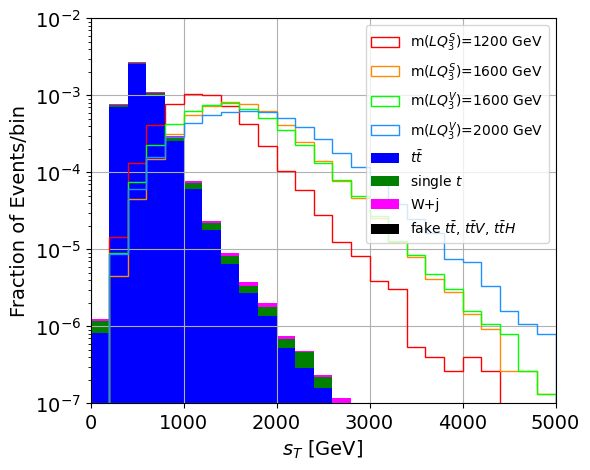

In [22]:
# Ejemple: sT
plot_variable('sT', X_SLQ_all, X_VLQ_all, X_B_all,
              masses_SLQ=[1200,1600],
              masses_VLQ=[1600,2000],
              bins=25,
            #   range=[20,2500] # MET
              range=[0,5000] # sT and HT and mT-METtau and m-b1b2
            #   range=[0.4,4.9] # dR-b1b2
              )

# 1. DATA FORMAT for CLASSIFIERS

In [23]:
# to save memory
del X_SLQ_all
del X_VLQ_all
del X_B_all

In [24]:
# ---------------------------
# Concatenate all for normalization
# ---------------------------
df_SM = pd.concat(df_B_all.values(), ignore_index=True)
del df_B_all

df_all = pd.concat([df_SM] + list(df_SLQ_all.values()) + list(df_VLQ_all.values()), ignore_index=True)

# ---------------------------
# Normalization
# ---------------------------
scaler = MinMaxScaler()
scaler.fit(df_all)

# Save the scaler
joblib.dump(scaler, mainfolder + 'saved-models/scaler_features_13TeV.pkl')

# Apply normalization
df_SM_norm = pd.DataFrame(scaler.transform(df_SM), columns=df_SM.columns)
df_SLQ_norm = {mass: pd.DataFrame(scaler.transform(df_SLQ_all[mass]), columns=df_SLQ_all[mass].columns) for mass in df_SLQ_all}
df_VLQ_norm = {mass: pd.DataFrame(scaler.transform(df_VLQ_all[mass]), columns=df_VLQ_all[mass].columns) for mass in df_VLQ_all}






# ---------------------------
# Divide datasets into train/val/test/pseudo
# ---------------------------
def split_class(df, test_ratio=0.25, val_ratio=0.10, pseudo_ratio=0.25):
    X = df.values
    aux_val_ratio = val_ratio / (1 - test_ratio)
    aux_pseudo_ratio = pseudo_ratio / (1 - test_ratio - val_ratio)

    X_aux, X_test = train_test_split(X, test_size=test_ratio, random_state=42, shuffle=True)
    X_aux2, X_val = train_test_split(X_aux, test_size=aux_val_ratio, random_state=42, shuffle=True)
    X_train, X_pseudo = train_test_split(X_aux2, test_size=aux_pseudo_ratio, random_state=42, shuffle=True)

    return X_train, X_val, X_test, X_pseudo



# ---------------------------
# Divide the datasets
# ---------------------------
split_SM = split_class(df_SM_norm)
split_SLQ = {mass: split_class(df_SLQ_norm[mass]) for mass in df_SLQ_norm}
split_VLQ = {mass: split_class(df_VLQ_norm[mass]) for mass in df_VLQ_norm}



# Example of how to use them
X_train_SM, X_val_SM, X_test_SM, X_pseudo_SM = split_SM
X_train_SLQ1200, X_val_SLQ1200, X_test_SLQ1200, X_pseudo_SLQ1200 = split_SLQ[1200]
X_train_VLQ1600, X_val_VLQ1600, X_test_VLQ1600, X_pseudo_VLQ1600 = split_VLQ[1600]

print('')
print('X_train_SM : ', X_train_SM.shape)
print('X_val_SM : ', X_val_SM.shape)
print('X_test_SM : ', X_test_SM.shape)
print('X_pseudo_SM : ', X_pseudo_SM.shape)

print('')
print('X_train_SLQ1200 : ', X_train_SLQ1200.shape)
print('X_val_SLQ1200 : ', X_val_SLQ1200.shape)
print('X_test_SLQ1200 : ', X_test_SLQ1200.shape)
print('X_pseudo_SLQ1200 : ', X_pseudo_SLQ1200.shape)

print('')
print('X_train_VLQ1600 : ', X_train_VLQ1600.shape)
print('X_val_VLQ1600 : ', X_val_VLQ1600.shape)
print('X_test_VLQ1600 : ', X_test_VLQ1600.shape)
print('X_pseudo_VLQ1600 : ', X_pseudo_VLQ1600.shape)


X_train_SM :  (300000, 53)
X_val_SM :  (75000, 53)
X_test_SM :  (187500, 53)
X_pseudo_SM :  (187500, 53)

X_train_SLQ1200 :  (15000, 53)
X_val_SLQ1200 :  (3750, 53)
X_test_SLQ1200 :  (9375, 53)
X_pseudo_SLQ1200 :  (9375, 53)

X_train_VLQ1600 :  (15000, 53)
X_val_VLQ1600 :  (3750, 53)
X_test_VLQ1600 :  (9375, 53)
X_pseudo_VLQ1600 :  (9375, 53)


In [25]:
# to save memory
del df_SM
del df_SLQ_all
del df_VLQ_all

# SM vs LQ

In [26]:
# Combine all LQ in a single DataFrame
df_LQ_list = list(df_SLQ_norm.values()) + list(df_VLQ_norm.values())
df_LQ_norm = pd.concat(df_LQ_list, ignore_index=True)


# Check, same number of events
n_SM = len(df_SM_norm)
n_LQ = len(df_LQ_norm)
n_events = min(n_SM, n_LQ)

print(n_SM, n_LQ, n_events)

df_SM_sample = df_SM_norm.sample(n=n_events, random_state=42)
df_LQ_sample = df_LQ_norm.sample(n=n_events, random_state=42)


# Create X, y
X = pd.concat([df_SM_sample, df_LQ_sample], ignore_index=True)
y = np.hstack([np.zeros(n_events), np.ones(n_events)])  # 0=SM, 1=LQ


def split_class(X, Y, test_ratio=0.25, val_ratio=0.25):

    aux_val_ratio = val_ratio / (1 - test_ratio)

    X_aux, X_test, Y_aux, Y_test = train_test_split(X, Y, test_size=test_ratio, random_state=42, shuffle=True)
    X_train, X_val, Y_train, Y_val = train_test_split(X_aux, Y_aux, test_size=val_ratio, random_state=42, shuffle=True)

    return X_train, X_val, X_test, Y_train, Y_val, Y_test



# Divide into train, validation and test
X_train, X_val, X_test, y_train, y_val, y_test = split_class(X, y)


print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

750000 750000 750000
(843750, 53)
(281250, 53)
(375000, 53)


In [27]:
# Train
xgb_clf = XGBClassifier(
    n_estimators=1200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss',
    early_stopping_rounds=50,
    tree_method='hist'
)

xgb_clf.fit(X_train, y_train,
            eval_set=[(X_train, y_train),
                      (X_val, y_val)],
            verbose=True)

# SAVE
xgb_clf.save_model(mainfolder + "saved-models/modelA_SMLQ_13TeV.json")

/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [05:30:55] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()


[0]	validation_0-logloss:0.65164	validation_1-logloss:0.65169
[1]	validation_0-logloss:0.61253	validation_1-logloss:0.61261
[2]	validation_0-logloss:0.57824	validation_1-logloss:0.57836
[3]	validation_0-logloss:0.54705	validation_1-logloss:0.54719
[4]	validation_0-logloss:0.51695	validation_1-logloss:0.51713
[5]	validation_0-logloss:0.48921	validation_1-logloss:0.48943
[6]	validation_0-logloss:0.46378	validation_1-logloss:0.46402
[7]	validation_0-logloss:0.44028	validation_1-logloss:0.44057
[8]	validation_0-logloss:0.41937	validation_1-logloss:0.41968
[9]	validation_0-logloss:0.39917	validation_1-logloss:0.39952
[10]	validation_0-logloss:0.38037	validation_1-logloss:0.38075
[11]	validation_0-logloss:0.36291	validation_1-logloss:0.36331
[12]	validation_0-logloss:0.34660	validation_1-logloss:0.34702
[13]	validation_0-logloss:0.33218	validation_1-logloss:0.33261
[14]	validation_0-logloss:0.31790	validation_1-logloss:0.31835
[15]	validation_0-logloss:0.30454	validation_1-logloss:0.30502
[1

In [28]:
from sklearn.model_selection import RandomizedSearchCV

# base model
xgb_base = XGBClassifier(
    n_estimators=500,  # it is low for tunning
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss',
    early_stopping_rounds=20, # it is low for tunnning
    tree_method='hist'
)

# hyperparameter grid
param_dist = {
    'max_depth': [3, 4, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.2, 0.4]
}


# Configure random search
# n_iter=10 -> tests n_iter random combinations
# cv=3 cross validation of 3
xgb_tune = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=10,
    scoring='neg_log_loss', # use logloss for consistency
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1 # all nodes
)

# train
xgb_tune.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

# print the results
print("Best hyperparameters:", xgb_tune.best_params_)
print("Best score:", xgb_tune.best_score_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [06:39:59] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()


Best hyperparameters: {'subsample': 0.8, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.1, 'gamma': 0.2, 'colsample_bytree': 0.6}
Best score: -0.0728329737409442


In [ ]:
# xgb_clf = XGBClassifier(
#     n_estimators=1200,
#     max_depth=5,
#     learning_rate=0.05,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     random_state=42,
#     use_label_encoder=False,
#     eval_metric='logloss',
#     early_stopping_rounds=50,
#     tree_method='hist'
# )

In [29]:
# save
best_model = xgb_tune.best_estimator_

best_model.save_model(mainfolder + "saved-models/modelA_SMLQ_13TeV_tuned.json")

Accuracy: 0.973, ROC-AUC: 0.99650


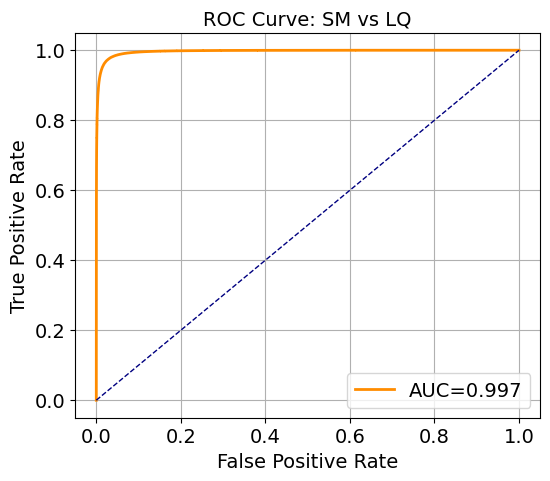

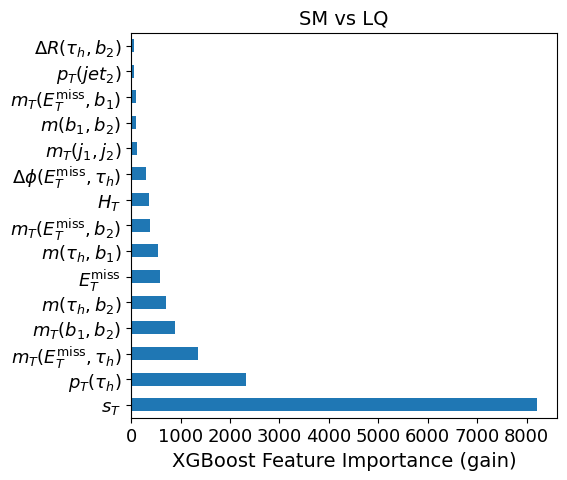

[52, 6, 47, 50, 36, 15, 35, 46, 17, 32, 51, 37, 45, 12, 21]


In [31]:
# LOAD
xgb_clf = XGBClassifier()
xgb_clf.load_model(mainfolder + "saved-models/modelA_SMLQ_13TeV_tuned.json")


# Evaluate
y_pred = xgb_clf.predict(X_test)
y_pred_proba = xgb_clf.predict_proba(X_test)[:,1]

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)
print(f"Accuracy: {acc:.3f}, ROC-AUC: {auc:.5f}")

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC={auc:.3f}')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel("False Positive Rate", fontsize=14)
plt.ylabel("True Positive Rate", fontsize=14)
plt.title("ROC Curve: SM vs LQ", fontsize=14)
plt.grid(True)
plt.legend(fontsize=14)
# plt.savefig(mainfolder + "saved-results/ROC_classA.pdf", bbox_inches='tight')
plt.show()


# Feature importance
keys = np.array([r'$p_T(b_1)$',r'$\eta(b_1)$',r'$\phi(b_1)$',
                 r'$p_T(b_2)$',r'$\eta(b_2)$',r'$\phi(b_2)$',
                 r'$p_T(\tau_h)$',r'$\eta(\tau_h)$',r'$\phi(\tau_h)$',
                 r'$p_T(jet_1)$',r'$\eta(jet_1)$',r'$\phi(jet_1)$',
                 r'$p_T(jet_2)$',r'$\eta(jet_2)$',r'$\phi(jet_2)$',
                 r'$E_T^{\mathrm{miss}}$',r'$\phi(E_T^{\mathrm{miss}})$',
                 r'$H_T$',r'$N_{\mathrm{jets}}$',r'$N_{b-\mathrm{jets}}$',
                 r'$\Delta R(\tau_h, b_1)$',r'$\Delta R(\tau_h, b_2)$',r'$\Delta R(b_1, b_2)$',
                 r'$\Delta R(j_1, b_1)$',r'$\Delta R(j_1, b_2)$',r'$\Delta R(j_1, \tau_h)$',
                 r'$\Delta R(j_2, b_1)$',r'$\Delta R(j_2, b_2)$',r'$\Delta R(j_2, \tau_h)$',
                 r'$\Delta R(j_1, j_2)$',
#                  r'$\Delta \phi(\tau_h, b_1)$',r'$\Delta \phi(\tau_h, b_2)$',r'$\Delta \phi(b_1, b_2)$',
                 r'$\Delta \phi(E_T^{\mathrm{miss}}, b_1)$',r'$\Delta \phi(E_T^{\mathrm{miss}}, b_2)$',r'$\Delta \phi(E_T^{\mathrm{miss}}, \tau_h)$',
                 r'$\Delta \phi(E_T^{\mathrm{miss}}, j_1)$',r'$\Delta \phi(E_T^{\mathrm{miss}}, j_2)$',
                 r'$m(\tau_h, b_1)$',r'$m(\tau_h, b_2)$',r'$m(b_1, b_2)$',
                 r'$m(j_1, b_1)$',r'$m(j_1, b_2)$',r'$m(j_1, \tau_h)$',
                 r'$m(j_2, b_1)$',r'$m(j_2, b_2)$',r'$m(j_2, \tau_h)$',
                 r'$m(j_1, j_2)$',
                 r'$m_T(E_T^{\mathrm{miss}}, b_1)$',r'$m_T(E_T^{\mathrm{miss}}, b_2)$',r'$m_T(E_T^{\mathrm{miss}}, \tau_h)$',
                 r'$m_T(E_T^{\mathrm{miss}}, j_1)$',r'$m_T(E_T^{\mathrm{miss}}, j_2)$',
                 r'$m_T(b_1, b_2)$',r'$m_T(j_1, j_2)$',r'$s_T$'])

feature_important = xgb_clf.get_booster().get_score(importance_type='gain')
values = list(feature_important.values())

data = pd.DataFrame(data=values, index=keys, columns=["score"]).sort_values(by = "score", ascending=False)
data.nlargest(15, columns="score").plot(kind='barh',figsize=(5.5,5)) ## plot top 15 features
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.xlabel("XGBoost Feature Importance (gain)", fontsize=14)
plt.legend( fontsize=14).remove()
plt.title(r'SM vs LQ', fontsize=14)
# plt.savefig(mainfolder + "saved-results/XG_feature_importance_classA.pdf", bbox_inches='tight')
plt.show()


# SELECT THE TOP INDICES
num_feats = 15

keys_list = list(keys)  # convert to list
top_names = data.nlargest(num_feats, columns="score").index.tolist()
feat_indices_LQSM = [keys_list.index(name) for name in top_names]

print(feat_indices_LQSM)

Accuracy: 0.974, ROC-AUC: 0.99662


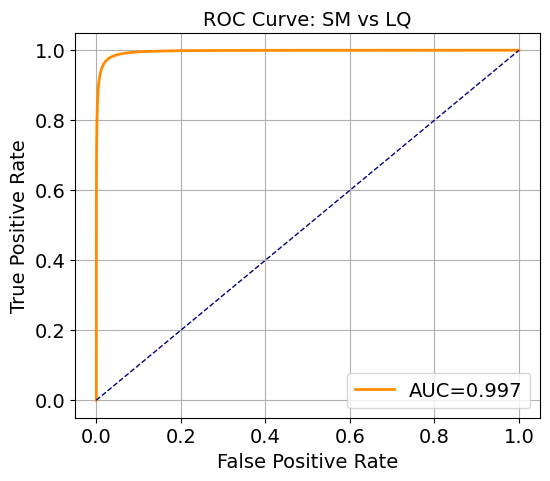

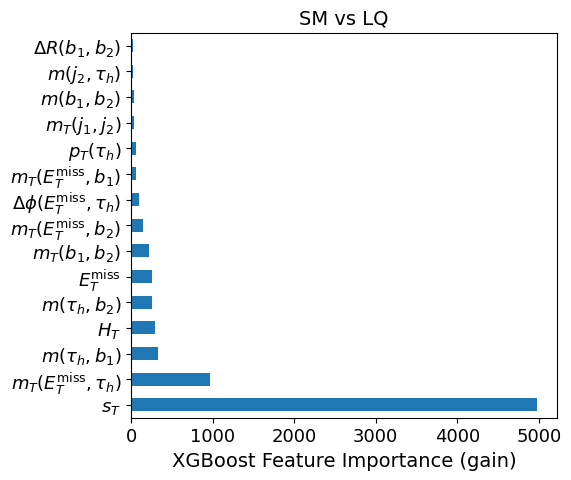

[52, 47, 35, 17, 36, 15, 50, 46, 32, 45, 6, 51, 37, 43, 22]


In [32]:
# LOAD
xgb_clf = XGBClassifier()
xgb_clf.load_model(mainfolder + "saved-models/modelA_SMLQ_13TeV.json")


# Evaluate
y_pred = xgb_clf.predict(X_test)
y_pred_proba = xgb_clf.predict_proba(X_test)[:,1]

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)
print(f"Accuracy: {acc:.3f}, ROC-AUC: {auc:.5f}")

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC={auc:.3f}')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel("False Positive Rate", fontsize=14)
plt.ylabel("True Positive Rate", fontsize=14)
plt.title("ROC Curve: SM vs LQ", fontsize=14)
plt.grid(True)
plt.legend(fontsize=14)
# plt.savefig(mainfolder + "saved-results/ROC_classA.pdf", bbox_inches='tight')
plt.show()


# Feature importance
keys = np.array([r'$p_T(b_1)$',r'$\eta(b_1)$',r'$\phi(b_1)$',
                 r'$p_T(b_2)$',r'$\eta(b_2)$',r'$\phi(b_2)$',
                 r'$p_T(\tau_h)$',r'$\eta(\tau_h)$',r'$\phi(\tau_h)$',
                 r'$p_T(jet_1)$',r'$\eta(jet_1)$',r'$\phi(jet_1)$',
                 r'$p_T(jet_2)$',r'$\eta(jet_2)$',r'$\phi(jet_2)$',
                 r'$E_T^{\mathrm{miss}}$',r'$\phi(E_T^{\mathrm{miss}})$',
                 r'$H_T$',r'$N_{\mathrm{jets}}$',r'$N_{b-\mathrm{jets}}$',
                 r'$\Delta R(\tau_h, b_1)$',r'$\Delta R(\tau_h, b_2)$',r'$\Delta R(b_1, b_2)$',
                 r'$\Delta R(j_1, b_1)$',r'$\Delta R(j_1, b_2)$',r'$\Delta R(j_1, \tau_h)$',
                 r'$\Delta R(j_2, b_1)$',r'$\Delta R(j_2, b_2)$',r'$\Delta R(j_2, \tau_h)$',
                 r'$\Delta R(j_1, j_2)$',
#                  r'$\Delta \phi(\tau_h, b_1)$',r'$\Delta \phi(\tau_h, b_2)$',r'$\Delta \phi(b_1, b_2)$',
                 r'$\Delta \phi(E_T^{\mathrm{miss}}, b_1)$',r'$\Delta \phi(E_T^{\mathrm{miss}}, b_2)$',r'$\Delta \phi(E_T^{\mathrm{miss}}, \tau_h)$',
                 r'$\Delta \phi(E_T^{\mathrm{miss}}, j_1)$',r'$\Delta \phi(E_T^{\mathrm{miss}}, j_2)$',
                 r'$m(\tau_h, b_1)$',r'$m(\tau_h, b_2)$',r'$m(b_1, b_2)$',
                 r'$m(j_1, b_1)$',r'$m(j_1, b_2)$',r'$m(j_1, \tau_h)$',
                 r'$m(j_2, b_1)$',r'$m(j_2, b_2)$',r'$m(j_2, \tau_h)$',
                 r'$m(j_1, j_2)$',
                 r'$m_T(E_T^{\mathrm{miss}}, b_1)$',r'$m_T(E_T^{\mathrm{miss}}, b_2)$',r'$m_T(E_T^{\mathrm{miss}}, \tau_h)$',
                 r'$m_T(E_T^{\mathrm{miss}}, j_1)$',r'$m_T(E_T^{\mathrm{miss}}, j_2)$',
                 r'$m_T(b_1, b_2)$',r'$m_T(j_1, j_2)$',r'$s_T$'])

feature_important = xgb_clf.get_booster().get_score(importance_type='gain')
values = list(feature_important.values())

data = pd.DataFrame(data=values, index=keys, columns=["score"]).sort_values(by = "score", ascending=False)
data.nlargest(15, columns="score").plot(kind='barh',figsize=(5.5,5)) ## plot top 15 features
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.xlabel("XGBoost Feature Importance (gain)", fontsize=14)
plt.legend( fontsize=14).remove()
plt.title(r'SM vs LQ', fontsize=14)
# plt.savefig(mainfolder + "saved-results/XG_feature_importance_classA.pdf", bbox_inches='tight')
plt.show()


# SELECT THE TOP INDICES
num_feats = 15

keys_list = list(keys)  # convert to list
top_names = data.nlargest(num_feats, columns="score").index.tolist()
feat_indices_LQSM = [keys_list.index(name) for name in top_names]

print(feat_indices_LQSM)

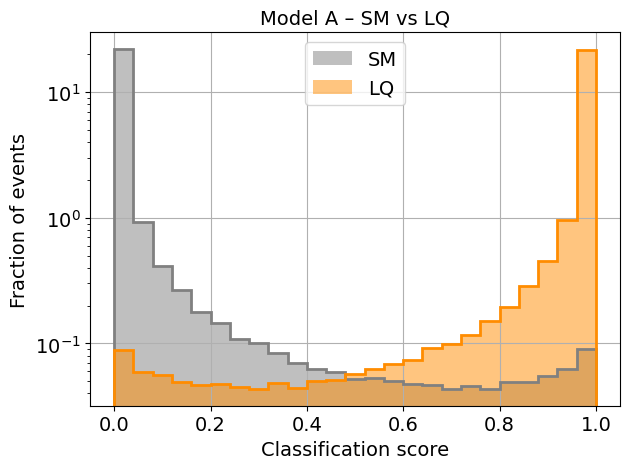

In [33]:

plt.hist(y_pred_proba[y_test < 0.5], bins=25, range=(0,1), density=True, histtype='step', color='gray', linewidth=2)
plt.hist(y_pred_proba[y_test > 0.5], bins=25, range=(0,1), density=True, histtype='step', color='darkorange', linewidth=2)

plt.hist(y_pred_proba[y_test < 0.5], bins=25, range=(0,1), density=True, color='gray', alpha=0.5, label=f'SM')#\nmean: {np.mean(pred_B):.2f}')
plt.hist(y_pred_proba[y_test > 0.5], bins=25, range=(0,1), density=True, color='darkorange', alpha=0.5, label=f'LQ')#\nmean: {np.mean(pred_s):.2f}')

plt.yscale('log')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.title(f'Model A – SM vs LQ', fontsize=14)
plt.xlabel("Classification score", fontsize=14)
plt.ylabel("Fraction of events", fontsize=14)
plt.grid(True)
plt.legend(fontsize=14)

plt.tight_layout()
# plt.savefig(mainfolder + 'saved-results/output_classA_multi.pdf', bbox_inches='tight')
plt.show()

# Exclusion and Discovery

In [34]:
# --- Clasificador A: SM vs LQ ---

scoresA_SM = xgb_clf.predict_proba( df_SM_norm )[:,1]

scoresA_SLQ = {}
scoresA_VLQ = {}

for m in masses_SLQ:
    scoresA_SLQ[m] = xgb_clf.predict_proba( df_SLQ_norm[m] )[:,1]

for m in masses_VLQ:
    scoresA_VLQ[m] = xgb_clf.predict_proba( df_VLQ_norm[m] )[:,1]

#### Aux functions

In [35]:
def generate_pseudo_1output_dis(scores_B, scores_S, N_B, N_S):

    sB = np.random.choice(scores_B, N_B, replace=True)
    sS = np.random.choice(scores_S, N_S, replace=True)

    scores = np.concatenate([sB, sS])

    return scores


def generate_pseudo_1output_exc(scores_B, N_B):

    sB = np.random.choice(scores_B, N_B, replace=True)

    return sB




In [36]:
def Z_asimov_dis(S, B):
    return np.sqrt( 2 * np.sum( (S+B) * np.log(1 + S/B) - S ) )


def Z_asimov_exc(S, B):
    return np.sqrt( 2 * np.sum( S - B * np.log(1 + S/B) ) )


def f_mu_hat(mu, N, S, B):

    return sum((ni*si)/(mu*si+bi) - si for ni,si,bi in zip(N,S,B))


def q0(N,S,B,mu_hat):
    """
    this is for discovery
    q0 = −2 log( L(0)/L(μ^) )
    """
    if mu_hat <= 0:
        return 0

    return -2 * sum( ni*np.log((bi)/(mu_hat*si+bi)) - bi + (mu_hat*si+bi) for ni,si,bi in zip(N,S,B)  )


def q1(N,S,B,mu_hat):
    """
    this is for exclusion
    q1 = −2 log( L(1)/L(μ^) )
    """
    if mu_hat > 1:
        return 0
    elif mu_hat > 0:
        return -2 * sum( ni*np.log((si+bi)/(mu_hat*si+bi)) - (1-mu_hat)*si  for ni,si,bi in zip(N,S,B)  )
    else:
        return -2 * sum( ni*np.log((si+bi)/(0.*si+bi)) - (1-0.)*si  for ni,si,bi in zip(N,S,B)  )

## Z-Loop for beta=0.5

B_expected:  1428
S_expected:  52
m_SLQ=  1000  GeV
m_VLQ=  1400  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  10.450927690389136
Z_asimov_dis_VLQ =  11.811511142678162

Z_asimov_exc_SLQ =  7.5591937700987994
Z_asimov_exc_VLQ =  8.233866862159644


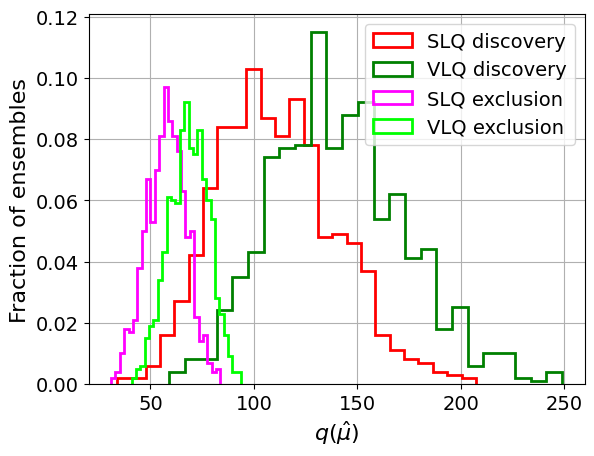


 Binned Likelihood:
Z_dis_SLQ =  10.442548910212961  +-  1.37066142226903
Z_dis_VLQ =  11.775201416601092  +-  1.3801294437164338

Z_exc_SLQ =  7.592816503224642  +-  0.622793049540552
Z_exc_VLQ =  8.27228151649386  +-  0.5810139264319849

------------------------------------------

B_expected:  1428
S_expected:  26
m_SLQ=  1100  GeV
m_VLQ=  1500  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  6.513460699661569
Z_asimov_dis_VLQ =  7.043325299265486

Z_asimov_exc_SLQ =  5.037263798538984
Z_asimov_exc_VLQ =  5.351724481380095


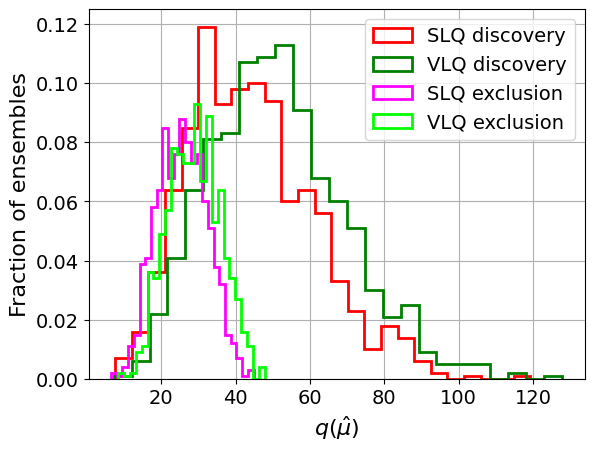


 Binned Likelihood:
Z_dis_SLQ =  6.493940078682027  +-  1.3079819136684858
Z_dis_VLQ =  7.077854851684968  +-  1.2802173539128054

Z_exc_SLQ =  5.040379301060346  +-  0.6606984217636396
Z_exc_VLQ =  5.3739388287523475  +-  0.6439090997438293

------------------------------------------

B_expected:  1428
S_expected:  13
m_SLQ=  1200  GeV
m_VLQ=  1600  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  3.8597193893530934
Z_asimov_dis_VLQ =  4.0606648007686665

Z_asimov_exc_SLQ =  3.2050728842998883
Z_asimov_exc_VLQ =  3.343841771698184


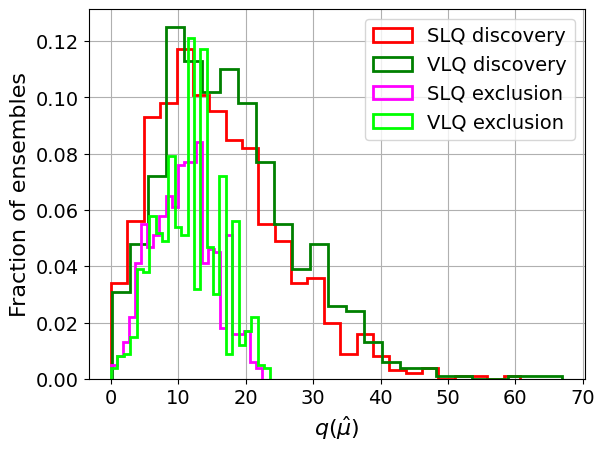


 Binned Likelihood:
Z_dis_SLQ =  3.8213204346015166  +-  1.2307963323270468
Z_dis_VLQ =  4.050186486509866  +-  1.1910199169600109

Z_exc_SLQ =  3.278423269269277  +-  0.6952754614072628
Z_exc_VLQ =  3.4111736211905863  +-  0.6938231797242655

------------------------------------------

B_expected:  1428
S_expected:  7
m_SLQ=  1300  GeV
m_VLQ=  1700  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  2.3386916033270073
Z_asimov_dis_VLQ =  2.407298554812501

Z_asimov_exc_SLQ =  2.0545254566571978
Z_asimov_exc_VLQ =  2.1076218404621727


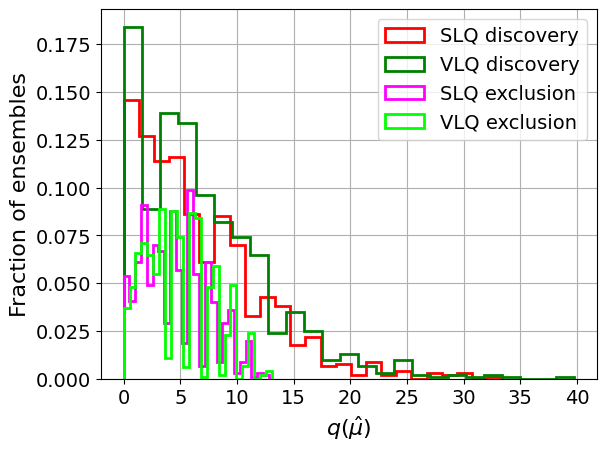


 Binned Likelihood:
Z_dis_SLQ =  2.3093270947123936  +-  1.1858292431347517
Z_dis_VLQ =  2.275763961669104  +-  1.2827841314247355

Z_exc_SLQ =  2.0890314583866747  +-  0.6808317782080145
Z_exc_VLQ =  2.1463263974231013  +-  0.6792574371047114

------------------------------------------

B_expected:  1428
S_expected:  3
m_SLQ=  1400  GeV
m_VLQ=  1800  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  1.109538538522325
Z_asimov_dis_VLQ =  1.1230607331543239

Z_asimov_exc_SLQ =  1.0342799163901737
Z_asimov_exc_VLQ =  1.046009831175566


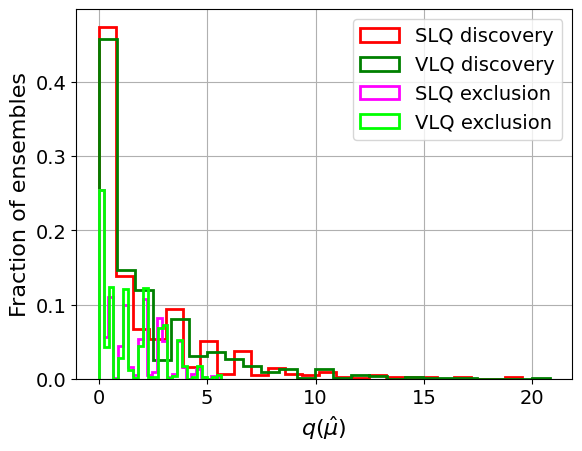


 Binned Likelihood:
Z_dis_SLQ =  1.1047416837788435  +-  1.3202334023028015
Z_dis_VLQ =  1.1331115301439143  +-  1.2343145497041208

Z_exc_SLQ =  1.0921043665635093  +-  0.6038856289498828
Z_exc_VLQ =  1.10325941068357  +-  0.6052430222705446

------------------------------------------

B_expected:  1428
S_expected:  2
m_SLQ=  1500  GeV
m_VLQ=  1900  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  0.7729243895144848
Z_asimov_dis_VLQ =  0.7710473616614407

Z_asimov_exc_SLQ =  0.7344704393972961
Z_asimov_exc_VLQ =  0.7327645530386807


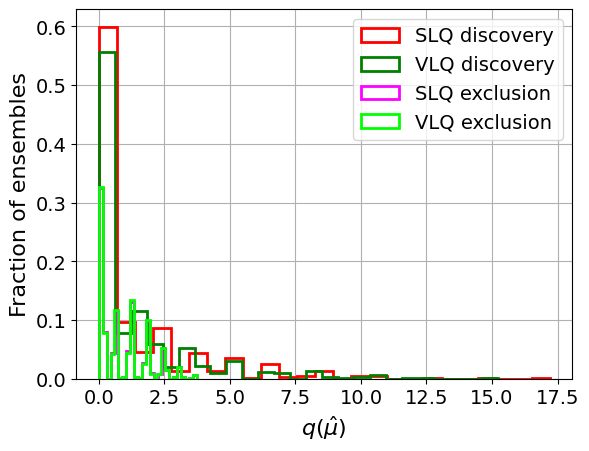


 Binned Likelihood:
Z_dis_SLQ =  0.7467089548457041  +-  1.528403170066882
Z_dis_VLQ =  0.732062596212714  +-  1.5193100148782284

Z_exc_SLQ =  0.8030847387002548  +-  0.5689846823567067
Z_exc_VLQ =  0.8014696792937843  +-  0.5686897830949555

------------------------------------------

B_expected:  1428
S_expected:  1
m_SLQ=  1600  GeV
m_VLQ=  2000  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  0.4030841058990185
Z_asimov_dis_VLQ =  0.39592208265816425

Z_asimov_exc_SLQ =  0.39197587515896976
Z_asimov_exc_VLQ =  0.3851975133190254


/tmp/ipykernel_5210/2567009407.py:160: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  mu_hat_exc_SLQ = fsolve(lambda x: f_mu_hat(x, N_pseudo_EXC, S_template_SLQ, B_template),0)[0] # search around mu=0 for exclusion


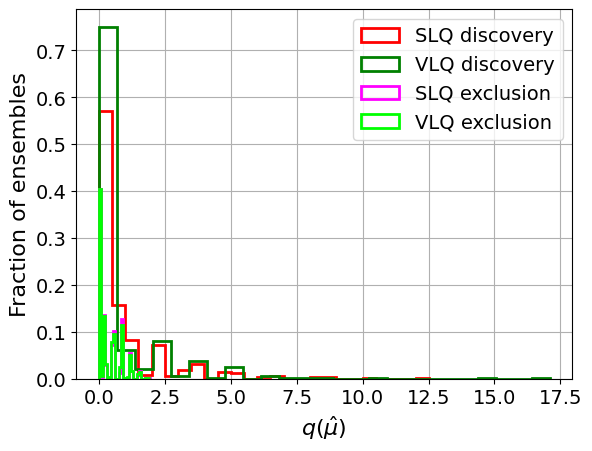


 Binned Likelihood:
Z_dis_SLQ =  0.3694782703533114  +-  2.242541100245164
Z_dis_VLQ =  0.3368020401812105  +-  2.2901603362302545

Z_exc_SLQ =  0.4590261139112278  +-  0.4857205734248656
Z_exc_VLQ =  0.45371206729218777  +-  0.4821094078779497

------------------------------------------

B_expected:  1428
S_expected:  1
m_SLQ=  1700  GeV
m_VLQ=  2100  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  0.4075760591493606
Z_asimov_dis_VLQ =  0.396965651480228

Z_asimov_exc_SLQ =  0.3962222133572216
Z_asimov_exc_VLQ =  0.38618529250580597


/tmp/ipykernel_5210/2567009407.py:167: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  mu_hat_exc_VLQ = fsolve(lambda x: f_mu_hat(x, N_pseudo_EXC, S_template_VLQ, B_template),0)[0] # search around mu=0 for exclusion


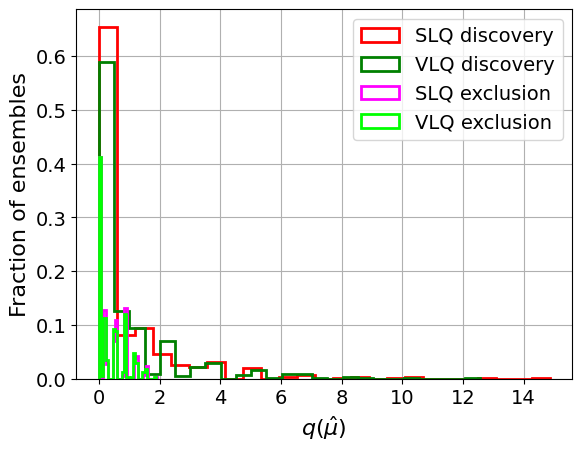


 Binned Likelihood:
Z_dis_SLQ =  0.3535344925612834  +-  2.4211623833036944
Z_dis_VLQ =  0.35361240759367546  +-  2.2673311497852056

Z_exc_SLQ =  0.46788444041779503  +-  0.49042126394112373
Z_exc_VLQ =  0.4626108911420024  +-  0.48193835766800663

------------------------------------------

B_expected:  1428
S_expected:  0
m_SLQ=  1800  GeV
m_VLQ=  2200  GeV
B_expected:  1428
S_expected:  0
m_SLQ=  1900  GeV
m_VLQ=  2300  GeV


In [37]:

S_expected = S_expected_SLQ

n_pseudo = 1000


N_bins = 16

# SM PDF
hist_SM, edges = np.histogram(scoresA_SM, bins=N_bins, range=(0,1))
B_template = hist_SM / (len(scoresA_SM) / B_expected)



Z_asimov_dis_SLQ = []
Z_asimov_exc_SLQ = []

Z_asimov_dis_VLQ = []
Z_asimov_exc_VLQ = []


Z_dis_SLQ = []
Z_exc_SLQ = []

Z_dis_VLQ = []
Z_exc_VLQ = []

Z_dis_std_SLQ = []
Z_exc_std_SLQ = []

Z_dis_std_VLQ = []
Z_exc_std_VLQ = []



for m_it in range(len(masses_SLQ)):

    print('B_expected: ', B_expected)
    print('S_expected: ', S_expected[m_it])

    mass_SLQ = masses_SLQ[m_it]
    mass_VLQ = masses_VLQ[m_it]

    print('m_SLQ= ', mass_SLQ, ' GeV' )
    print('m_VLQ= ', mass_VLQ, ' GeV' )

    if S_expected[m_it] == 0:

        Z_asimov_dis_SLQ.append(0)
        Z_asimov_exc_SLQ.append(0)

        Z_asimov_dis_VLQ.append(0)
        Z_asimov_exc_VLQ.append(0)

        Z_dis_SLQ.append(0)
        Z_dis_std_SLQ.append(1)
        Z_exc_SLQ.append(0)
        Z_exc_std_SLQ.append(1)

        Z_dis_VLQ.append(0)
        Z_dis_std_VLQ.append(1)
        Z_exc_VLQ.append(0)
        Z_exc_std_VLQ.append(1)

        continue


    ###################
    # ASIMOV EXPECTED #
    ###################

    # SLQ PDF
    hist_SLQ, _ = np.histogram(scoresA_SLQ[mass_SLQ], bins=N_bins, range=(0,1))
    S_template_SLQ = hist_SLQ / (len(scoresA_SLQ[mass_SLQ]) / S_expected[m_it])

    # VLQ PDF
    hist_VLQ, _ = np.histogram(scoresA_VLQ[mass_VLQ], bins=N_bins, range=(0,1))
    S_template_VLQ = hist_VLQ / (len(scoresA_VLQ[mass_VLQ]) / S_expected[m_it])


    Z_asimov_dis_SLQ_it = Z_asimov_dis(S_template_SLQ, B_template)
    Z_asimov_exc_SLQ_it = Z_asimov_exc(S_template_SLQ, B_template)

    Z_asimov_dis_VLQ_it = Z_asimov_dis(S_template_VLQ, B_template)
    Z_asimov_exc_VLQ_it = Z_asimov_exc(S_template_VLQ, B_template)


    Z_asimov_dis_SLQ.append(Z_asimov_dis_SLQ_it)
    Z_asimov_exc_SLQ.append(Z_asimov_exc_SLQ_it)

    Z_asimov_dis_VLQ.append(Z_asimov_dis_VLQ_it)
    Z_asimov_exc_VLQ.append(Z_asimov_exc_VLQ_it)


    print('\n Asimov datasets:')
    print('Z_asimov_dis_SLQ = ', Z_asimov_dis_SLQ_it)
    print('Z_asimov_dis_VLQ = ', Z_asimov_dis_VLQ_it)
    print()
    print('Z_asimov_exc_SLQ = ', Z_asimov_exc_SLQ_it)
    print('Z_asimov_exc_VLQ = ', Z_asimov_exc_VLQ_it)





    #####################
    # BINNED LIKELIHOOD #
    #####################

    q_dis_SLQ = []
    q_exc_SLQ = []

    q_dis_VLQ = []
    q_exc_VLQ = []


    for pexp_it in range(n_pseudo):

        N_B = np.random.poisson(B_expected)
        N_S = np.random.poisson(S_expected[m_it])


        # pseudo experiment (DISCOVERY: SM vs SM+LQ)
        # SLQ
        scoresA_pseudo_SLQ = generate_pseudo_1output_dis( scoresA_SM, scoresA_SLQ[mass_SLQ], N_B, N_S )
        hist, _ = np.histogram(scoresA_pseudo_SLQ, bins=N_bins, range=(0,1))
        N_pseudo_SLQ = hist

        # VLQ
        scoresA_pseudo_VLQ = generate_pseudo_1output_dis( scoresA_SM, scoresA_VLQ[mass_VLQ], N_B, N_S )
        hist, _ = np.histogram(scoresA_pseudo_VLQ, bins=N_bins, range=(0,1))
        N_pseudo_VLQ = hist


        # pseudo experiment (EXCLUSION: SM ONLY)
        # SLQ and VLQ (since no signal)
        scoresA_pseudo_EXC = generate_pseudo_1output_exc( scoresA_SM, N_B )
        hist, _ = np.histogram(scoresA_pseudo_EXC, bins=N_bins, range=(0,1))
        N_pseudo_EXC = hist



        # DISCOVERY (mu_hat=1 idedally)
        # SLQ
        mu_hat_dis_SLQ = fsolve(lambda x: f_mu_hat(x, N_pseudo_SLQ, S_template_SLQ, B_template),1)[0] # search around mu=1 for discovery

        q_dis_SLQ_it = q0(N_pseudo_SLQ, S_template_SLQ, B_template, mu_hat_dis_SLQ)
        q_dis_SLQ.append(q_dis_SLQ_it)


        # VLQ
        mu_hat_dis_VLQ = fsolve(lambda x: f_mu_hat(x, N_pseudo_VLQ, S_template_VLQ, B_template),1)[0] # search around mu=1 for discovery

        q_dis_VLQ_it = q0(N_pseudo_VLQ, S_template_VLQ, B_template, mu_hat_dis_VLQ)
        q_dis_VLQ.append(q_dis_VLQ_it)



        # EXCLUSION (mu_hat=0 idedally)
        # SLQ
        mu_hat_exc_SLQ = fsolve(lambda x: f_mu_hat(x, N_pseudo_EXC, S_template_SLQ, B_template),0)[0] # search around mu=0 for exclusion

        q_exc_SLQ_it = q1(N_pseudo_EXC, S_template_SLQ, B_template, mu_hat_exc_SLQ)
        q_exc_SLQ.append(q_exc_SLQ_it)


        # VLQ
        mu_hat_exc_VLQ = fsolve(lambda x: f_mu_hat(x, N_pseudo_EXC, S_template_VLQ, B_template),0)[0] # search around mu=0 for exclusion

        q_exc_VLQ_it = q1(N_pseudo_EXC, S_template_VLQ, B_template, mu_hat_exc_VLQ)
        q_exc_VLQ.append(q_exc_VLQ_it)




    # Histogram of q_muhats
    weights = np.ones_like(q_dis_SLQ)/float(len(q_dis_SLQ))
    nMIX, binsMIX, patchesMIX = plt.hist(q_dis_SLQ, 25, weights=weights, histtype='step', color='red', linewidth=2, label='SLQ discovery')
    weights = np.ones_like(q_dis_VLQ)/float(len(q_dis_VLQ))
    nMIX, binsMIX, patchesMIX = plt.hist(q_dis_VLQ, 25, weights=weights, histtype='step', color='green', linewidth=2, label='VLQ discovery')

    weights = np.ones_like(q_exc_SLQ)/float(len(q_exc_SLQ))
    nMIX, binsMIX, patchesMIX = plt.hist(q_exc_SLQ, 25, weights=weights, histtype='step', color='magenta', linewidth=2, label='SLQ exclusion')
    weights = np.ones_like(q_exc_VLQ)/float(len(q_exc_VLQ))
    nMIX, binsMIX, patchesMIX = plt.hist(q_exc_VLQ, 25, weights=weights, histtype='step', color='lime', linewidth=2, label='VLQ exclusion')
    #plt.xlim(0,1)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.xlabel(r"$q(\hat{\mu})$",fontsize=16)
    plt.ylabel("Fraction of ensembles",fontsize=16)
    plt.grid()
    plt.legend(fontsize=14)
    plt.show()




    Z_dis_SLQ_it = np.sqrt(np.median(q_dis_SLQ))
    Z_dis_std_SLQ_it = np.std(q_dis_SLQ) / (2. * Z_dis_SLQ_it)

    Z_exc_SLQ_it = np.sqrt(np.median(q_exc_SLQ))
    Z_exc_std_SLQ_it = np.std(q_exc_SLQ) / (2. * Z_exc_SLQ_it)


    Z_dis_VLQ_it = np.sqrt(np.median(q_dis_VLQ))
    Z_dis_std_VLQ_it = np.std(q_dis_VLQ) / (2. * Z_dis_VLQ_it)

    Z_exc_VLQ_it = np.sqrt(np.median(q_exc_VLQ))
    Z_exc_std_VLQ_it = np.std(q_exc_VLQ) / (2. * Z_exc_VLQ_it)


    Z_dis_SLQ.append(Z_dis_SLQ_it)
    Z_dis_std_SLQ.append(Z_dis_std_SLQ_it)
    Z_exc_SLQ.append(Z_exc_SLQ_it)
    Z_exc_std_SLQ.append(Z_exc_std_SLQ_it)

    Z_dis_VLQ.append(Z_dis_VLQ_it)
    Z_dis_std_VLQ.append(Z_dis_std_VLQ_it)
    Z_exc_VLQ.append(Z_exc_VLQ_it)
    Z_exc_std_VLQ.append(Z_exc_std_VLQ_it)


    print('\n Binned Likelihood:')
    print('Z_dis_SLQ = ', Z_dis_SLQ_it, ' +- ', Z_dis_std_SLQ_it)
    print('Z_dis_VLQ = ', Z_dis_VLQ_it, ' +- ', Z_dis_std_VLQ_it)
    print()
    print('Z_exc_SLQ = ', Z_exc_SLQ_it, ' +- ', Z_exc_std_SLQ_it)
    print('Z_exc_VLQ = ', Z_exc_VLQ_it, ' +- ', Z_exc_std_VLQ_it)


    print('\n------------------------------------------\n')

m_asimov_dis_SLQ =  1157.0312069900153  GeV
m_asimov_dis_VLQ =  1568.5068012365225  GeV

m_asimov_exc_SLQ =  1340.1542387138006  GeV
m_asimov_exc_VLQ =  1743.5910869001639  GeV

m_BL_dis_SLQ =  1155.8979681972667  GeV
m_BL_dis_VLQ =  1568.6288787631072  GeV

m_BL_exc_SLQ =  1344.5546956320443  GeV
m_BL_exc_VLQ =  1748.076756032626  GeV


/tmp/ipykernel_5210/2666492215.py:21: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  m_asimov_dis_SLQ = fsolve(lambda x: f_Z_asimov_dis_SLQ(x) - Z_dis,1600)[0]
/tmp/ipykernel_5210/2666492215.py:22: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  m_asimov_exc_SLQ = fsolve(lambda x: f_Z_asimov_exc_SLQ(x) - Z_exc,1600)[0]
/tmp/ipykernel_5210/2666492215.py:24: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  m_asimov_dis_VLQ = fsolve(lambda x: f_Z_asimov_dis_VLQ(x) - Z_dis,1600)[0]
/tmp/ipykernel_5210/2666492215.py:25: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  m_asimov_exc_VLQ = fsolve(lambda x: f_Z_asimov_exc_VLQ(x) - Z_exc,1600)[0]
/tmp/ipykernel_5210/2666492215.py:27: RuntimeWarning

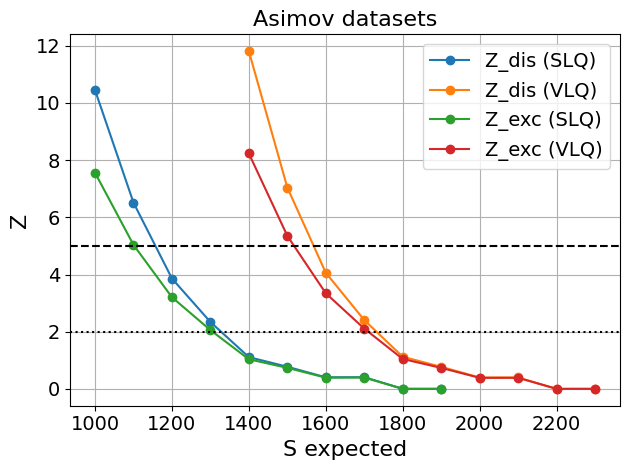

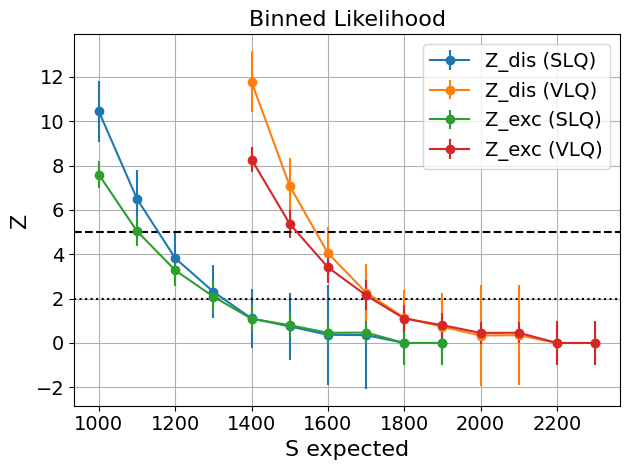

In [38]:
# Z value that we want
Z_dis = 5
Z_exc = stats.norm.isf(0.05)

#  interpolate
f_Z_asimov_dis_SLQ = interp1d(masses_SLQ, Z_asimov_dis_SLQ, kind='linear', fill_value="extrapolate")
f_Z_asimov_exc_SLQ = interp1d(masses_SLQ, Z_asimov_exc_SLQ, kind='linear', fill_value="extrapolate")

f_Z_asimov_dis_VLQ = interp1d(masses_VLQ, Z_asimov_dis_VLQ, kind='linear', fill_value="extrapolate")
f_Z_asimov_exc_VLQ = interp1d(masses_VLQ, Z_asimov_exc_VLQ, kind='linear', fill_value="extrapolate")

f_Z_BL_dis_SLQ = interp1d(masses_SLQ, Z_dis_SLQ, kind='linear', fill_value="extrapolate")
f_Z_BL_exc_SLQ = interp1d(masses_SLQ, Z_exc_SLQ, kind='linear', fill_value="extrapolate")

f_Z_BL_dis_VLQ = interp1d(masses_VLQ, Z_dis_VLQ, kind='linear', fill_value="extrapolate")
f_Z_BL_exc_VLQ = interp1d(masses_VLQ, Z_exc_VLQ, kind='linear', fill_value="extrapolate")


# find the mass such that we get Z for discovery or exclusion

m_asimov_dis_SLQ = fsolve(lambda x: f_Z_asimov_dis_SLQ(x) - Z_dis,1600)[0]
m_asimov_exc_SLQ = fsolve(lambda x: f_Z_asimov_exc_SLQ(x) - Z_exc,1600)[0]

m_asimov_dis_VLQ = fsolve(lambda x: f_Z_asimov_dis_VLQ(x) - Z_dis,1600)[0]
m_asimov_exc_VLQ = fsolve(lambda x: f_Z_asimov_exc_VLQ(x) - Z_exc,1600)[0]

m_BL_dis_SLQ = fsolve(lambda x: f_Z_BL_dis_SLQ(x) - Z_dis,1600)[0]
m_BL_exc_SLQ = fsolve(lambda x: f_Z_BL_exc_SLQ(x) - Z_exc,1600)[0]

m_BL_dis_VLQ = fsolve(lambda x: f_Z_BL_dis_VLQ(x) - Z_dis,1600)[0]
m_BL_exc_VLQ = fsolve(lambda x: f_Z_BL_exc_VLQ(x) - Z_exc,1600)[0]



print(r'm_asimov_dis_SLQ = ', m_asimov_dis_SLQ, ' GeV')
print(r'm_asimov_dis_VLQ = ', m_asimov_dis_VLQ, ' GeV')
print()
print(r'm_asimov_exc_SLQ = ', m_asimov_exc_SLQ, ' GeV')
print(r'm_asimov_exc_VLQ = ', m_asimov_exc_VLQ, ' GeV')

print()
print(r'm_BL_dis_SLQ = ', m_BL_dis_SLQ, ' GeV')
print(r'm_BL_dis_VLQ = ', m_BL_dis_VLQ, ' GeV')
print()
print(r'm_BL_exc_SLQ = ', m_BL_exc_SLQ, ' GeV')
print(r'm_BL_exc_VLQ = ', m_BL_exc_VLQ, ' GeV')





# plot ASIMOV DATASETS

plt.plot(masses_SLQ, Z_asimov_dis_SLQ, 'o-', label='Z_dis (SLQ)')
plt.plot(masses_VLQ, Z_asimov_dis_VLQ, 'o-', label='Z_dis (VLQ)')

plt.plot(masses_SLQ, Z_asimov_exc_SLQ, 'o-', label='Z_exc (SLQ)')
plt.plot(masses_VLQ, Z_asimov_exc_VLQ, 'o-', label='Z_exc (VLQ)')

plt.axhline(y=5, linestyle='--', color='black')
plt.axhline(y=2, linestyle=':', color='black')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel("S expected",fontsize=16)
plt.ylabel("Z",fontsize=16)
plt.title('Asimov datasets', fontsize=16)
plt.grid(True)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()



# plot BINNED LIKEHOOD

plt.errorbar(masses_SLQ, Z_dis_SLQ, yerr=Z_dis_std_SLQ, fmt='o-', label='Z_dis (SLQ)')
plt.errorbar(masses_VLQ, Z_dis_VLQ, yerr=Z_dis_std_VLQ, fmt='o-', label='Z_dis (VLQ)')

plt.errorbar(masses_SLQ, Z_exc_SLQ, yerr=Z_exc_std_SLQ, fmt='o-', label='Z_exc (SLQ)')
plt.errorbar(masses_VLQ, Z_exc_VLQ, yerr=Z_exc_std_VLQ, fmt='o-', label='Z_exc (VLQ)')

plt.axhline(y=5, linestyle='--', color='black')
plt.axhline(y=2, linestyle=':', color='black')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel("S expected",fontsize=16)
plt.ylabel("Z",fontsize=16)
plt.title('Binned Likelihood', fontsize=16)
plt.grid(True)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()

# Z-Loop for all betas

In [39]:
# Z value that we want
Z_dis = 5
Z_exc = stats.norm.isf(0.05)
Z_exc

np.float64(1.6448536269514729)

In [40]:

betas = [0.0, 0.1, 0.3, 0.5, 0.7, 0.9, 1.0]

n_pseudo = 1000


N_bins = 16

# SM PDF
hist_SM, edges = np.histogram(scoresA_SM, bins=N_bins, range=(0,1))
B_template = hist_SM / (len(scoresA_SM) / B_expected)



m_asimov_dis_SLQ_13TeV = []
m_asimov_exc_SLQ_13TeV = []

m_asimov_dis_VLQ_13TeV = []
m_asimov_exc_VLQ_13TeV = []


m_BL_dis_SLQ_13TeV = []
m_BL_exc_SLQ_13TeV = []

m_BL_dis_VLQ_13TeV = []
m_BL_exc_VLQ_13TeV = []


m_BL_dis_SLQ_low_13TeV = []
m_BL_exc_SLQ_low_13TeV = []

m_BL_dis_VLQ_low_13TeV = []
m_BL_exc_VLQ_low_13TeV = []


m_BL_dis_SLQ_high_13TeV = []
m_BL_exc_SLQ_high_13TeV = []

m_BL_dis_VLQ_high_13TeV = []
m_BL_exc_VLQ_high_13TeV = []


for b_it in betas:

    print('beta: ', b_it)

    Z_asimov_dis_SLQ = []
    Z_asimov_exc_SLQ = []

    Z_asimov_dis_VLQ = []
    Z_asimov_exc_VLQ = []


    Z_dis_SLQ = []
    Z_exc_SLQ = []

    Z_dis_VLQ = []
    Z_exc_VLQ = []

    Z_dis_std_SLQ = []
    Z_exc_std_SLQ = []

    Z_dis_std_VLQ = []
    Z_exc_std_VLQ = []


    for m_it in range(len(masses_SLQ)):

        print('B_expected: ', B_expected)

        S_expected_SLQ = fid_xsec_SLQ_13TeV(masses_SLQ[m_it], b_it) * Lum
        S_expected_VLQ = fid_xsec_VLQ_13TeV(masses_VLQ[m_it], b_it) * Lum

        print('S_expected_SLQ: ', S_expected_SLQ)
        print('S_expected_VLQ: ', S_expected_VLQ)

        mass_SLQ = masses_SLQ[m_it]
        mass_VLQ = masses_VLQ[m_it]

        print('m_SLQ= ', mass_SLQ, ' GeV' )
        print('m_VLQ= ', mass_VLQ, ' GeV' )


        if S_expected_SLQ == 0 or S_expected_VLQ == 0:

            Z_asimov_dis_SLQ.append(0)
            Z_asimov_exc_SLQ.append(0)

            Z_asimov_dis_VLQ.append(0)
            Z_asimov_exc_VLQ.append(0)

            Z_dis_SLQ.append(0)
            Z_dis_std_SLQ.append(1)
            Z_exc_SLQ.append(0)
            Z_exc_std_SLQ.append(1)

            Z_dis_VLQ.append(0)
            Z_dis_std_VLQ.append(1)
            Z_exc_VLQ.append(0)
            Z_exc_std_VLQ.append(1)

            continue



        ###################
        # ASIMOV EXPECTED #
        ###################

        # SLQ PDF
        hist_SLQ, _ = np.histogram(scoresA_SLQ[mass_SLQ], bins=N_bins, range=(0,1))
        S_template_SLQ = hist_SLQ / (len(scoresA_SLQ[mass_SLQ]) / S_expected_SLQ)

        # SLQ PDF
        hist_VLQ, _ = np.histogram(scoresA_VLQ[mass_VLQ], bins=N_bins, range=(0,1))
        S_template_VLQ = hist_VLQ / (len(scoresA_VLQ[mass_VLQ]) / S_expected_VLQ)


        Z_asimov_dis_SLQ_it = Z_asimov_dis(S_template_SLQ, B_template)
        Z_asimov_exc_SLQ_it = Z_asimov_exc(S_template_SLQ, B_template)

        Z_asimov_dis_VLQ_it = Z_asimov_dis(S_template_VLQ, B_template)
        Z_asimov_exc_VLQ_it = Z_asimov_exc(S_template_VLQ, B_template)


        Z_asimov_dis_SLQ.append(Z_asimov_dis_SLQ_it)
        Z_asimov_exc_SLQ.append(Z_asimov_exc_SLQ_it)

        Z_asimov_dis_VLQ.append(Z_asimov_dis_VLQ_it)
        Z_asimov_exc_VLQ.append(Z_asimov_exc_VLQ_it)


        print('\n Asimov datasets:')
        print('Z_asimov_dis_SLQ = ', Z_asimov_dis_SLQ_it)
        print('Z_asimov_dis_VLQ = ', Z_asimov_dis_VLQ_it)
        print()
        print('Z_asimov_exc_SLQ = ', Z_asimov_exc_SLQ_it)
        print('Z_asimov_exc_VLQ = ', Z_asimov_exc_VLQ_it)





        #####################
        # BINNED LIKELIHOOD #
        #####################

        q_dis_SLQ = []
        q_exc_SLQ = []

        q_dis_VLQ = []
        q_exc_VLQ = []


        for pexp_it in range(n_pseudo):

            N_B = np.random.poisson(B_expected)
            N_S_SLQ = np.random.poisson(S_expected_SLQ)
            N_S_VLQ = np.random.poisson(S_expected_VLQ)


            # pseudo experiment (DISCOVERY: SM vs SM+LQ)
            # SLQ
            scoresA_pseudo_SLQ = generate_pseudo_1output_dis( scoresA_SM, scoresA_SLQ[mass_SLQ], N_B, N_S_SLQ )
            hist, _ = np.histogram(scoresA_pseudo_SLQ, bins=N_bins, range=(0,1))
            N_pseudo_SLQ = hist

            # VLQ
            scoresA_pseudo_VLQ = generate_pseudo_1output_dis( scoresA_SM, scoresA_VLQ[mass_VLQ], N_B, N_S_VLQ )
            hist, _ = np.histogram(scoresA_pseudo_VLQ, bins=N_bins, range=(0,1))
            N_pseudo_VLQ = hist


            # pseudo experiment (EXCLUSION: SM ONLY)
            # SLQ and VLQ (since no signal)
            scoresA_pseudo_EXC = generate_pseudo_1output_exc( scoresA_SM, N_B )
            hist, _ = np.histogram(scoresA_pseudo_EXC, bins=N_bins, range=(0,1))
            N_pseudo_EXC = hist



            # DISCOVERY (mu_hat=1 idedally)
            # SLQ
            mu_hat_dis_SLQ = fsolve(lambda x: f_mu_hat(x, N_pseudo_SLQ, S_template_SLQ, B_template),1)[0] # search around mu=1 for discovery

            q_dis_SLQ_it = q0(N_pseudo_SLQ, S_template_SLQ, B_template, mu_hat_dis_SLQ)
            q_dis_SLQ.append(q_dis_SLQ_it)


            # VLQ
            mu_hat_dis_VLQ = fsolve(lambda x: f_mu_hat(x, N_pseudo_VLQ, S_template_VLQ, B_template),1)[0] # search around mu=1 for discovery

            q_dis_VLQ_it = q0(N_pseudo_VLQ, S_template_VLQ, B_template, mu_hat_dis_VLQ)
            q_dis_VLQ.append(q_dis_VLQ_it)



            # EXCLUSION (mu_hat=0 idedally)
            # SLQ
            mu_hat_exc_SLQ = fsolve(lambda x: f_mu_hat(x, N_pseudo_EXC, S_template_SLQ, B_template),0)[0] # search around mu=0 for exclusion

            q_exc_SLQ_it = q1(N_pseudo_EXC, S_template_SLQ, B_template, mu_hat_exc_SLQ)
            q_exc_SLQ.append(q_exc_SLQ_it)


            # VLQ
            mu_hat_exc_VLQ = fsolve(lambda x: f_mu_hat(x, N_pseudo_EXC, S_template_VLQ, B_template),0)[0] # search around mu=0 for exclusion

            q_exc_VLQ_it = q1(N_pseudo_EXC, S_template_VLQ, B_template, mu_hat_exc_VLQ)
            q_exc_VLQ.append(q_exc_VLQ_it)




        # Histogram of q_muhats
        weights = np.ones_like(q_dis_SLQ)/float(len(q_dis_SLQ))
        nMIX, binsMIX, patchesMIX = plt.hist(q_dis_SLQ, 25, weights=weights, histtype='step', color='red', linewidth=2, label='SLQ discovery')
        weights = np.ones_like(q_dis_VLQ)/float(len(q_dis_VLQ))
        nMIX, binsMIX, patchesMIX = plt.hist(q_dis_VLQ, 25, weights=weights, histtype='step', color='green', linewidth=2, label='VLQ discovery')

        weights = np.ones_like(q_exc_SLQ)/float(len(q_exc_SLQ))
        nMIX, binsMIX, patchesMIX = plt.hist(q_exc_SLQ, 25, weights=weights, histtype='step', color='magenta', linewidth=2, label='SLQ exclusion')
        weights = np.ones_like(q_exc_VLQ)/float(len(q_exc_VLQ))
        nMIX, binsMIX, patchesMIX = plt.hist(q_exc_VLQ, 25, weights=weights, histtype='step', color='lime', linewidth=2, label='VLQ exclusion')
        #plt.xlim(0,1)
        plt.xticks(fontsize=14)
        plt.yticks(fontsize=14)
        plt.xlabel("$q(\hat{\mu})$",fontsize=16)
        plt.ylabel("Fraction of ensembles",fontsize=16)
        plt.grid()
        plt.legend(fontsize=14)
        plt.show()




        Z_dis_SLQ_it = np.sqrt(np.median(q_dis_SLQ))
        Z_dis_std_SLQ_it = np.std(q_dis_SLQ) / (2. * Z_dis_SLQ_it)

        Z_exc_SLQ_it = np.sqrt(np.median(q_exc_SLQ))
        Z_exc_std_SLQ_it = np.std(q_exc_SLQ) / (2. * Z_exc_SLQ_it)


        Z_dis_VLQ_it = np.sqrt(np.median(q_dis_VLQ))
        Z_dis_std_VLQ_it = np.std(q_dis_VLQ) / (2. * Z_dis_VLQ_it)

        Z_exc_VLQ_it = np.sqrt(np.median(q_exc_VLQ))
        Z_exc_std_VLQ_it = np.std(q_exc_VLQ) / (2. * Z_exc_VLQ_it)


        Z_dis_SLQ.append(Z_dis_SLQ_it)
        Z_dis_std_SLQ.append(Z_dis_std_SLQ_it)
        Z_exc_SLQ.append(Z_exc_SLQ_it)
        Z_exc_std_SLQ.append(Z_exc_std_SLQ_it)

        Z_dis_VLQ.append(Z_dis_VLQ_it)
        Z_dis_std_VLQ.append(Z_dis_std_VLQ_it)
        Z_exc_VLQ.append(Z_exc_VLQ_it)
        Z_exc_std_VLQ.append(Z_exc_std_VLQ_it)


        print('\n Binned Likelihood:')
        print('Z_dis_SLQ = ', Z_dis_SLQ_it, ' +- ', Z_dis_std_SLQ_it)
        print('Z_dis_VLQ = ', Z_dis_VLQ_it, ' +- ', Z_dis_std_VLQ_it)
        print()
        print('Z_exc_SLQ = ', Z_exc_SLQ_it, ' +- ', Z_exc_std_SLQ_it)
        print('Z_exc_VLQ = ', Z_exc_VLQ_it, ' +- ', Z_exc_std_VLQ_it)



        print('\n------------------------------------------\n')


    Z_dis_SLQ_low = [i-j for i,j in zip(Z_dis_SLQ, Z_dis_std_SLQ)]
    Z_exc_SLQ_low = [i-j for i,j in zip(Z_exc_SLQ, Z_exc_std_SLQ)]

    Z_dis_VLQ_low = [i-j for i,j in zip(Z_dis_VLQ, Z_dis_std_VLQ)]
    Z_exc_VLQ_low = [i-j for i,j in zip(Z_exc_VLQ, Z_exc_std_VLQ)]

    Z_dis_SLQ_high = [i+j for i,j in zip(Z_dis_SLQ, Z_dis_std_SLQ)]
    Z_exc_SLQ_high = [i+j for i,j in zip(Z_exc_SLQ, Z_exc_std_SLQ)]

    Z_dis_VLQ_high = [i+j for i,j in zip(Z_dis_VLQ, Z_dis_std_VLQ)]
    Z_exc_VLQ_high = [i+j for i,j in zip(Z_exc_VLQ, Z_exc_std_VLQ)]

    #  interpolate
    f_Z_asimov_dis_SLQ = interp1d(masses_SLQ, Z_asimov_dis_SLQ, kind='linear', fill_value="extrapolate")
    f_Z_asimov_exc_SLQ = interp1d(masses_SLQ, Z_asimov_exc_SLQ, kind='linear', fill_value="extrapolate")

    f_Z_asimov_dis_VLQ = interp1d(masses_VLQ, Z_asimov_dis_VLQ, kind='linear', fill_value="extrapolate")
    f_Z_asimov_exc_VLQ = interp1d(masses_VLQ, Z_asimov_exc_VLQ, kind='linear', fill_value="extrapolate")

    f_Z_BL_dis_SLQ = interp1d(masses_SLQ, Z_dis_SLQ, kind='linear', fill_value="extrapolate")
    f_Z_BL_exc_SLQ = interp1d(masses_SLQ, Z_exc_SLQ, kind='linear', fill_value="extrapolate")

    f_Z_BL_dis_VLQ = interp1d(masses_VLQ, Z_dis_VLQ, kind='linear', fill_value="extrapolate")
    f_Z_BL_exc_VLQ = interp1d(masses_VLQ, Z_exc_VLQ, kind='linear', fill_value="extrapolate")

    f_Z_BL_dis_SLQ_low = interp1d(masses_SLQ, Z_dis_SLQ_low, kind='linear', fill_value="extrapolate")
    f_Z_BL_exc_SLQ_low = interp1d(masses_SLQ, Z_exc_SLQ_low, kind='linear', fill_value="extrapolate")

    f_Z_BL_dis_VLQ_low = interp1d(masses_VLQ, Z_dis_VLQ_low, kind='linear', fill_value="extrapolate")
    f_Z_BL_exc_VLQ_low = interp1d(masses_VLQ, Z_exc_VLQ_low, kind='linear', fill_value="extrapolate")

    f_Z_BL_dis_SLQ_high = interp1d(masses_SLQ, Z_dis_SLQ_high, kind='linear', fill_value="extrapolate")
    f_Z_BL_exc_SLQ_high = interp1d(masses_SLQ, Z_exc_SLQ_high, kind='linear', fill_value="extrapolate")

    f_Z_BL_dis_VLQ_high = interp1d(masses_VLQ, Z_dis_VLQ_high, kind='linear', fill_value="extrapolate")
    f_Z_BL_exc_VLQ_high = interp1d(masses_VLQ, Z_exc_VLQ_high, kind='linear', fill_value="extrapolate")


    # find the mass such that we get Z for discovery or exclusion

    m_asimov_dis_SLQ_aux = fsolve(lambda x: f_Z_asimov_dis_SLQ(x) - Z_dis,1000)[0]
    m_asimov_exc_SLQ_aux = fsolve(lambda x: f_Z_asimov_exc_SLQ(x) - Z_exc,1100)[0]

    m_asimov_dis_VLQ_aux = fsolve(lambda x: f_Z_asimov_dis_VLQ(x) - Z_dis,1400)[0]
    m_asimov_exc_VLQ_aux = fsolve(lambda x: f_Z_asimov_exc_VLQ(x) - Z_exc,1400)[0]

    m_BL_dis_SLQ_aux = fsolve(lambda x: f_Z_BL_dis_SLQ(x) - Z_dis,1000)[0]
    m_BL_exc_SLQ_aux = fsolve(lambda x: f_Z_BL_exc_SLQ(x) - Z_exc,1100)[0]

    m_BL_dis_VLQ_aux = fsolve(lambda x: f_Z_BL_dis_VLQ(x) - Z_dis,1400)[0]
    m_BL_exc_VLQ_aux = fsolve(lambda x: f_Z_BL_exc_VLQ(x) - Z_exc,1400)[0]

    m_BL_dis_SLQ_low_aux = fsolve(lambda x: f_Z_BL_dis_SLQ_low(x) - Z_dis,1000)[0]
    m_BL_exc_SLQ_low_aux = fsolve(lambda x: f_Z_BL_exc_SLQ_low(x) - Z_exc,1100)[0]

    m_BL_dis_VLQ_low_aux = fsolve(lambda x: f_Z_BL_dis_VLQ_low(x) - Z_dis,1400)[0]
    m_BL_exc_VLQ_low_aux = fsolve(lambda x: f_Z_BL_exc_VLQ_low(x) - Z_exc,1400)[0]

    m_BL_dis_SLQ_high_aux = fsolve(lambda x: f_Z_BL_dis_SLQ_high(x) - Z_dis,1000)[0]
    m_BL_exc_SLQ_high_aux = fsolve(lambda x: f_Z_BL_exc_SLQ_high(x) - Z_exc,1100)[0]

    m_BL_dis_VLQ_high_aux = fsolve(lambda x: f_Z_BL_dis_VLQ_high(x) - Z_dis,1400)[0]
    m_BL_exc_VLQ_high_aux = fsolve(lambda x: f_Z_BL_exc_VLQ_high(x) - Z_exc,1400)[0]


    print('m_asimov_dis_SLQ = ', m_asimov_dis_SLQ_aux, ' GeV')
    print('m_asimov_dis_VLQ = ', m_asimov_dis_VLQ_aux, ' GeV')
    print()
    print('m_asimov_exc_VLQ = ', m_asimov_exc_VLQ_aux, ' GeV')
    print('m_asimov_exc_SLQ = ', m_asimov_exc_SLQ_aux, ' GeV')

    print()
    print('m_BL_dis_SLQ = ', m_BL_dis_SLQ_aux, ' GeV')
    print('m_BL_dis_VLQ = ', m_BL_dis_VLQ_aux, ' GeV')
    print()
    print('m_BL_exc_VLQ = ', m_BL_exc_VLQ_aux, ' GeV')
    print('m_BL_exc_SLQ = ', m_BL_exc_SLQ_aux, ' GeV')


    m_asimov_dis_SLQ_13TeV.append(m_asimov_dis_SLQ_aux)
    m_asimov_exc_SLQ_13TeV.append(m_asimov_exc_SLQ_aux)

    m_asimov_dis_VLQ_13TeV.append(m_asimov_dis_VLQ_aux)
    m_asimov_exc_VLQ_13TeV.append(m_asimov_exc_VLQ_aux)


    m_BL_dis_SLQ_13TeV.append(m_BL_dis_SLQ_aux)
    m_BL_exc_SLQ_13TeV.append(m_BL_exc_SLQ_aux)

    m_BL_dis_VLQ_13TeV.append(m_BL_dis_VLQ_aux)
    m_BL_exc_VLQ_13TeV.append(m_BL_exc_VLQ_aux)


    m_BL_dis_SLQ_low_13TeV.append(m_BL_dis_SLQ_low_aux)
    m_BL_exc_SLQ_low_13TeV.append(m_BL_exc_SLQ_low_aux)

    m_BL_dis_VLQ_low_13TeV.append(m_BL_dis_VLQ_low_aux)
    m_BL_exc_VLQ_low_13TeV.append(m_BL_exc_VLQ_low_aux)


    m_BL_dis_SLQ_high_13TeV.append(m_BL_dis_SLQ_high_aux)
    m_BL_exc_SLQ_high_13TeV.append(m_BL_exc_SLQ_high_aux)

    m_BL_dis_VLQ_high_13TeV.append(m_BL_dis_VLQ_high_aux)
    m_BL_exc_VLQ_high_13TeV.append(m_BL_exc_VLQ_high_aux)


    print('\n######################################\n')


Output hidden; open in https://colab.research.google.com to view.

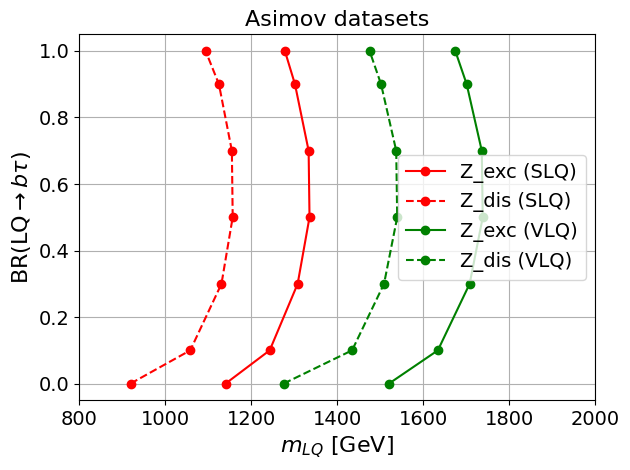

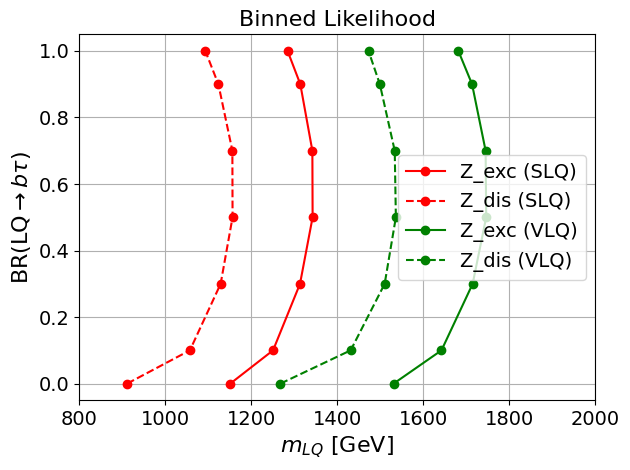

In [41]:
# plot ASIMOV DATASETS

plt.plot(m_asimov_exc_SLQ_13TeV, betas, 'o-', c='red', label='Z_exc (SLQ)')
plt.plot(m_asimov_dis_SLQ_13TeV, betas, 'o--', c='red', label='Z_dis (SLQ)')

plt.plot(m_asimov_exc_VLQ_13TeV, betas, 'o-', c='green', label='Z_exc (VLQ)')
plt.plot(m_asimov_dis_VLQ_13TeV, betas, 'o--', c='green', label='Z_dis (VLQ)')

plt.xlim(800,2000)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel(r"$m_{LQ}$ [GeV]",fontsize=16)
plt.ylabel(r"BR(LQ$\rightarrow b \tau$)",fontsize=16)
plt.title('Asimov datasets', fontsize=16)
plt.grid(True)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()



# plot BINNED LIKEHOOD

plt.plot(m_BL_exc_SLQ_13TeV, betas, 'o-', c='red', label='Z_exc (SLQ)')
plt.plot(m_BL_dis_SLQ_13TeV, betas, 'o--', c='red', label='Z_dis (SLQ)')

plt.plot(m_BL_exc_VLQ_13TeV, betas, 'o-', c='green', label='Z_exc (VLQ)')
plt.plot(m_BL_dis_VLQ_13TeV, betas, 'o--', c='green', label='Z_dis (VLQ)')

plt.xlim(800,2000)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel(r"$m_{LQ}$ [GeV]",fontsize=16)
plt.ylabel(r"BR(LQ$\rightarrow b \tau$)",fontsize=16)
plt.title('Binned Likelihood', fontsize=16)
plt.grid(True)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:

# SAVE

file_path = mainfolder + 'saved-results/Z13TeV_err.txt'

# Combine all data into a single array
data_to_save = np.column_stack([
    betas,
    m_asimov_exc_SLQ_13TeV,
    m_asimov_dis_SLQ_13TeV,
    m_asimov_exc_VLQ_13TeV,
    m_asimov_dis_VLQ_13TeV,
    m_BL_exc_SLQ_13TeV,
    m_BL_dis_SLQ_13TeV,
    m_BL_exc_VLQ_13TeV,
    m_BL_dis_VLQ_13TeV,
    m_BL_exc_SLQ_low_13TeV,
    m_BL_dis_SLQ_low_13TeV,
    m_BL_exc_VLQ_low_13TeV,
    m_BL_dis_VLQ_low_13TeV,
    m_BL_exc_SLQ_high_13TeV,
    m_BL_dis_SLQ_high_13TeV,
    m_BL_exc_VLQ_high_13TeV,
    m_BL_dis_VLQ_high_13TeV
])

# Save data to a text file
np.savetxt(file_path, data_to_save, fmt='%.6f',
           header='# betas m_asimov_exc_SLQ_13TeV m_asimov_dis_SLQ_13TeV m_asimov_exc_VLQ_13TeV m_asimov_dis_VLQ_13TeV m_BL_exc_SLQ_13TeV m_BL_dis_SLQ_13TeV m_BL_exc_VLQ_13TeV m_BL_dis_VLQ_13TeV m_BL_exc_SLQ_low_13TeV m_BL_dis_SLQ_low_13TeV m_BL_exc_VLQ_low_13TeV m_BL_dis_VLQ_low_13TeV m_BL_exc_SLQ_high_13TeV m_BL_dis_SLQ_high_13TeV m_BL_exc_VLQ_high_13TeV m_BL_dis_VLQ_high_13TeV',
           comments='')

print(f"Data saved to: {file_path}")


Data saved to: /content/drive/MyDrive/Trabajos/leptoquarks/scalar-vs-vector/03-pythons2026-junio/saved-results/Z13TeV_err.txt


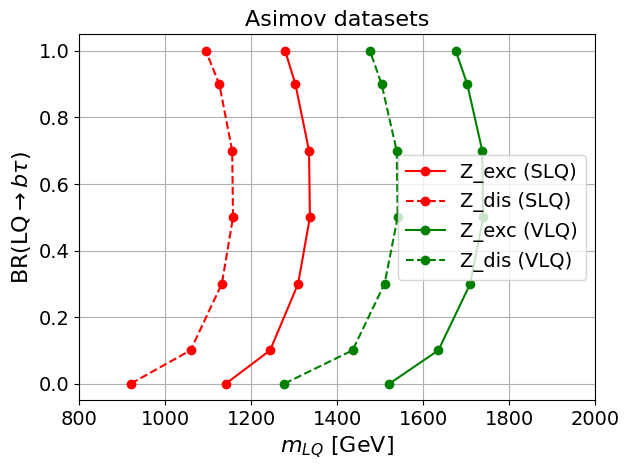

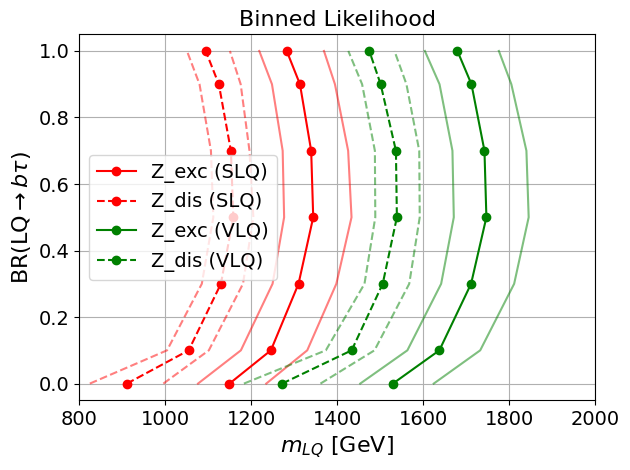

In [ ]:

# LOAD

file_path = mainfolder + 'saved-results/Z13TeV_err.txt'

loaded_data = np.loadtxt(file_path)

loaded_betas = loaded_data[:, 0]
m_asimov_exc_SLQ_13TeV = loaded_data[:, 1]
m_asimov_dis_SLQ_13TeV = loaded_data[:, 2]
m_asimov_exc_VLQ_13TeV = loaded_data[:, 3]
m_asimov_dis_VLQ_13TeV = loaded_data[:, 4]
m_BL_exc_SLQ_13TeV = loaded_data[:, 5]
m_BL_dis_SLQ_13TeV = loaded_data[:, 6]
m_BL_exc_VLQ_13TeV = loaded_data[:, 7]
m_BL_dis_VLQ_13TeV = loaded_data[:, 8]
m_BL_exc_SLQ_low_13TeV = loaded_data[:, 9]
m_BL_dis_SLQ_low_13TeV = loaded_data[:, 10]
m_BL_exc_VLQ_low_13TeV = loaded_data[:, 11]
m_BL_dis_VLQ_low_13TeV = loaded_data[:, 12]
m_BL_exc_SLQ_high_13TeV = loaded_data[:, 13]
m_BL_dis_SLQ_high_13TeV = loaded_data[:, 14]
m_BL_exc_VLQ_high_13TeV = loaded_data[:, 15]
m_BL_dis_VLQ_high_13TeV = loaded_data[:, 16]



# plot ASIMOV DATASETS

plt.plot(m_asimov_exc_SLQ_13TeV, betas, 'o-', c='red', label='Z_exc (SLQ)')
plt.plot(m_asimov_dis_SLQ_13TeV, betas, 'o--', c='red', label='Z_dis (SLQ)')

plt.plot(m_asimov_exc_VLQ_13TeV, betas, 'o-', c='green', label='Z_exc (VLQ)')
plt.plot(m_asimov_dis_VLQ_13TeV, betas, 'o--', c='green', label='Z_dis (VLQ)')

# plt.axhline(y=5, linestyle='--', color='black')
# plt.axhline(y=2, linestyle=':', color='black')
plt.xlim(800,2000)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel(r"$m_{LQ}$ [GeV]",fontsize=16)
plt.ylabel(r"BR(LQ$\rightarrow b \tau$)",fontsize=16)
plt.title('Asimov datasets', fontsize=16)
plt.grid(True)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()



# plot BINNED LIKEHOOD

plt.plot(m_BL_exc_SLQ_13TeV, betas, 'o-', c='red', label='Z_exc (SLQ)')
plt.plot(m_BL_exc_SLQ_low_13TeV, betas, '-', c='red', alpha=0.5)
plt.plot(m_BL_exc_SLQ_high_13TeV, betas, '-', c='red', alpha=0.5)
plt.plot(m_BL_dis_SLQ_13TeV, betas, 'o--', c='red', label='Z_dis (SLQ)')
plt.plot(m_BL_dis_SLQ_low_13TeV, betas, '--', c='red', alpha=0.5)
plt.plot(m_BL_dis_SLQ_high_13TeV, betas, '--', c='red', alpha=0.5)

plt.plot(m_BL_exc_VLQ_13TeV, betas, 'o-', c='green', label='Z_exc (VLQ)')
plt.plot(m_BL_exc_VLQ_low_13TeV, betas, '-', c='green', alpha=0.5)
plt.plot(m_BL_exc_VLQ_high_13TeV, betas, '-', c='green', alpha=0.5)
plt.plot(m_BL_dis_VLQ_13TeV, betas, 'o--', c='green', label='Z_dis (VLQ)')
plt.plot(m_BL_dis_VLQ_low_13TeV, betas, '--', c='green', alpha=0.5)
plt.plot(m_BL_dis_VLQ_high_13TeV, betas, '--', c='green', alpha=0.5)

# plt.axhline(y=5, linestyle='--', color='black')
# plt.axhline(y=2, linestyle=':', color='black')
plt.xlim(800,2000)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel(r"$m_{LQ}$ [GeV]",fontsize=16)
plt.ylabel(r"BR(LQ$\rightarrow b \tau$)",fontsize=16)
plt.title('Binned Likelihood', fontsize=16)
plt.grid(True)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()